## Definição e carregamento de bases de dados para Matching

Para a estimação do modelo, serão utilizadas as seguintes covariáveis:
-> Variáveis escolhidas e suas fontes:  
 * PIB per Capita (IBGE)
 * População (IBGE)
 * Participação Setorial no PIB (IBGE)
 * Educação média (RAIS)
 * Receita Corrente Municipal Bruta (IPEADATA)

 Obs: todos as base de dados são carregadas diretamente do repositório no github. No caso da RAIS, se desejar alterar os parâmetros de busca no database, o código está como comentário.


## Importação das bibliotecas utilizadas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import sidrapy
import ipeadatapy as ipea
import basedosdados as bd
import numpy as np
import math
import time
from scipy.stats import zscore
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


## Carregamento de dados via SIDRA
* PIB per Capita
* População
* Participação do setor de serviços

In [2]:
df_pib_per_capita = pd.read_csv("https://github.com/mvtp23/TCC/releases/download/database_ibge/pib_per_capita_municipios_2003_2023.csv",sep=',', encoding='utf-8-sig')

In [3]:
df_pib_per_capita

,cod_municipio,ano,pib_per_capita,nome_municipio,sigla_uf
0,1100015,2003,143222.0,Alta Floresta D'Oeste,RO
1,1100023,2003,539636.0,Ariquemes,RO
2,1100031,2003,40985.0,Cabixi,RO
3,1100049,2003,622437.0,Cacoal,RO
4,1100056,2003,99983.0,Cerejeiras,RO
...,...,...,...,...,...
116901,5222005,2023,914943.0,Vianópolis,GO
116902,5222054,2023,677600.0,Vicentinópolis,GO
116903,5222203,2023,201846.0,Vila Boa,GO
116904,5222302,2023,444209.0,Vila Propício,GO


In [4]:
df_populacao = pd.read_csv("https://github.com/mvtp23/TCC/releases/download/database_ibge/populacao_municipios_2003_2023.csv",sep=',', encoding='utf-8-sig')

In [5]:
df_populacao.head(10)

,Unnamed: 0,cod_municipio,nome_municipio,sigla_uf,ano,populacao
0,0,1100015,Alta Floresta D'Oeste,RO,2003,27563.0
1,1,1100015,Alta Floresta D'Oeste,RO,2004,29001.0
2,2,1100015,Alta Floresta D'Oeste,RO,2005,28629.0
3,3,1100015,Alta Floresta D'Oeste,RO,2006,29005.0
4,4,1100015,Alta Floresta D'Oeste,RO,2008,24577.0
5,5,1100015,Alta Floresta D'Oeste,RO,2009,24354.0
6,6,1100015,Alta Floresta D'Oeste,RO,2011,24228.0
7,7,1100015,Alta Floresta D'Oeste,RO,2012,24069.0
8,8,1100015,Alta Floresta D'Oeste,RO,2013,25728.0
9,9,1100015,Alta Floresta D'Oeste,RO,2014,25652.0


In [6]:
df_pib_setor = pd.read_csv("https://github.com/mvtp23/TCC/releases/download/database_ibge/pib_setorial_municipios_2010_2021.csv",sep=',', encoding='utf-8-sig')

In [7]:
df_pib_setor["pib_servicos"] = df_pib_setor["pib_total"] * df_pib_setor["part_servicos"]

In [8]:
df_pib_setor[df_pib_setor["ano"]==2021]

,cod_municipio,nome_municipio,sigla_uf,ano,pib_total,part_agropecuaria,part_industria,part_servicos,part_adm_publica,pib_servicos
100260,1100015,Alta Floresta D'Oeste,RO,2021,734467.0,45.48,4.07,25.18,25.28,1.849388e+07
100261,1100023,Ariquemes,RO,2021,3211294.0,10.50,14.61,46.86,28.03,1.504812e+08
100262,1100031,Cabixi,RO,2021,238414.0,60.14,3.57,15.78,20.50,3.762173e+06
100263,1100049,Cacoal,RO,2021,2792506.0,14.17,9.83,49.86,26.13,1.392343e+08
100264,1100056,Cerejeiras,RO,2021,743062.0,24.82,4.49,50.51,20.19,3.753206e+07
...,...,...,...,...,...,...,...,...,...,...
105825,5222005,Vianópolis,GO,2021,858016.0,52.51,5.54,32.38,9.57,2.778256e+07
105826,5222054,Vicentinópolis,GO,2021,480210.0,43.42,19.55,25.28,11.75,1.213971e+07
105827,5222203,Vila Boa,GO,2021,179924.0,35.25,18.27,24.32,22.16,4.375752e+06
105828,5222302,Vila Propício,GO,2021,308035.0,53.51,19.43,15.83,11.23,4.876194e+06


In [9]:
df_ibge = pd.merge(df_pib_per_capita, df_populacao, on=['cod_municipio','ano', 'sigla_uf',"nome_municipio"], how='inner')
df_ibge = pd.merge(df_ibge, df_pib_setor, on = ["cod_municipio", "ano", "sigla_uf", "nome_municipio"], how='inner')
df_ibge.head(10)

,cod_municipio,ano,pib_per_capita,nome_municipio,sigla_uf,Unnamed: 0,populacao,pib_total,part_agropecuaria,part_industria,part_servicos,part_adm_publica,pib_servicos
0,1100015,2003,143222.0,Alta Floresta D'Oeste,RO,0,27563.0,143222.0,30.95,9.57,24.85,34.63,3559066.70
1,1100023,2003,539636.0,Ariquemes,RO,19,79680.0,539636.0,9.74,22.18,41.40,26.68,22340930.40
2,1100031,2003,40985.0,Cabixi,RO,38,7478.0,40985.0,44.89,4.92,16.39,33.79,671744.15
3,1100049,2003,622437.0,Cacoal,RO,57,74758.0,622437.0,10.39,21.27,45.46,22.88,28295986.02
4,1100056,2003,99983.0,Cerejeiras,RO,76,17794.0,99983.0,18.48,7.90,39.46,34.16,3945329.18
5,1100064,2003,103363.0,Colorado do Oeste,RO,95,20412.0,103363.0,21.79,14.03,29.42,34.76,3040939.46
6,1100072,2003,57284.0,Corumbiara,RO,114,10022.0,57284.0,54.34,3.91,11.02,30.74,631269.68
7,1100080,2003,50996.0,Costa Marques,RO,133,10255.0,50996.0,11.71,27.85,23.67,36.77,1207075.32
8,1100098,2003,153425.0,Espigão D'Oeste,RO,152,26468.0,153425.0,24.51,18.34,26.89,30.25,4125598.25
9,1100106,2003,247248.0,Guajará-Mirim,RO,171,39728.0,247248.0,4.38,4.73,58.15,32.74,14377471.20


In [10]:
df_ibge = df_ibge[["ano", "cod_municipio", "nome_municipio", "sigla_uf", "pib_per_capita", "populacao", "pib_servicos","part_servicos","part_industria","part_agropecuaria","part_adm_publica"]]
df_ibge

,ano,cod_municipio,nome_municipio,sigla_uf,pib_per_capita,populacao,pib_servicos,part_servicos,part_industria,part_agropecuaria,part_adm_publica
0,2003,1100015,Alta Floresta D'Oeste,RO,143222.0,27563.0,3559066.70,24.85,9.57,30.95,34.63
1,2003,1100023,Ariquemes,RO,539636.0,79680.0,22340930.40,41.40,22.18,9.74,26.68
2,2003,1100031,Cabixi,RO,40985.0,7478.0,671744.15,16.39,4.92,44.89,33.79
3,2003,1100049,Cacoal,RO,622437.0,74758.0,28295986.02,45.46,21.27,10.39,22.88
4,2003,1100056,Cerejeiras,RO,99983.0,17794.0,3945329.18,39.46,7.90,18.48,34.16
...,...,...,...,...,...,...,...,...,...,...,...
105772,2023,5222005,Vianópolis,GO,914943.0,14956.0,NaN,NaN,NaN,NaN,NaN
105773,2023,5222054,Vicentinópolis,GO,677600.0,8768.0,NaN,NaN,NaN,NaN,NaN
105774,2023,5222203,Vila Boa,GO,201846.0,4215.0,NaN,NaN,NaN,NaN,NaN
105775,2023,5222302,Vila Propício,GO,444209.0,5815.0,NaN,NaN,NaN,NaN,NaN


In [11]:
# Transformações e crescimento do PIB per capita por município

df_ibge['log_pib_per_capita'] = np.log(df_ibge['pib_per_capita'])
df_ibge['log_populacao']      = np.log(df_ibge['populacao'])
df_ibge['log_pib_servicos'] = np.log(df_ibge["pib_servicos"])

df_ibge = df_ibge.drop(columns=["pib_per_capita", "populacao", "pib_servicos"])

# Crescimento anual do PIB per capita por município
# Usando diff() dentro de cada grupo evita que o 1º ano de um município
# herde o último valor do município anterior
df_ibge = df_ibge.sort_values(["cod_municipio", "ano"])

df_ibge["%_pib_per_capita"] = (
    df_ibge
    .groupby("cod_municipio")["log_pib_per_capita"]
    .diff()                          # Δlog ≈ taxa de crescimento contínua
    .pipe(lambda s: np.exp(s) - 1)   # converte para taxa discreta
)

df_ibge["%_pib_servicos"] = (
    df_ibge
    .groupby("cod_municipio")["log_pib_servicos"]
    .diff()                          # Δlog ≈ taxa de crescimento contínua
    .pipe(lambda s: np.exp(s) - 1)   # converte para taxa discreta
)


df_ibge

,ano,cod_municipio,nome_municipio,sigla_uf,part_servicos,part_industria,part_agropecuaria,part_adm_publica,log_pib_per_capita,log_populacao,log_pib_servicos,%_pib_per_capita,%_pib_servicos
0,2003,1100015,Alta Floresta D'Oeste,RO,24.85,9.57,30.95,34.63,11.872151,10.224230,15.085009,NaN,NaN
5560,2004,1100015,Alta Floresta D'Oeste,RO,24.16,18.52,25.60,31.71,12.066759,10.275086,15.251457,0.214834,0.181102
11120,2005,1100015,Alta Floresta D'Oeste,RO,25.67,8.68,26.93,38.71,12.026509,10.262175,15.271832,-0.039450,0.020584
16684,2006,1100015,Alta Floresta D'Oeste,RO,23.46,8.31,25.44,42.79,12.036499,10.275224,15.191796,0.010040,-0.076917
22248,2008,1100015,Alta Floresta D'Oeste,RO,26.59,6.35,33.71,33.34,12.425056,10.109566,15.705591,0.474850,0.671622
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83496,2019,5300108,Brasília,DF,51.56,3.89,0.41,44.14,19.427228,14.919199,23.369974,0.073765,0.100443
89066,2020,5300108,Brasília,DF,48.48,4.55,0.68,46.29,19.398433,14.932339,23.279584,-0.028384,-0.086425
94636,2021,5300108,Brasília,DF,49.68,3.98,0.89,45.45,19.474797,14.945080,23.380399,0.079355,0.106072
100206,2022,5300108,Brasília,DF,NaN,NaN,NaN,NaN,19.610928,14.851318,NaN,0.145833,NaN


## Carregamento de dados via IPEA Data  


In [12]:
df_recorrm = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database_ipead/receita_municipal_2010_2023.parquet")

In [13]:
df_recorrm.head(10)

,CODE,RAW DATE,TERCODIGO,YEAR,NIVNOME,VALUE (R$)
DATE,,,,,,
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4301073,2010,Municípios,8963643.63
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4316972,2010,Municípios,9470921.93
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,5107578,2010,Municípios,11842374.62
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4321469,2010,Municípios,8907258.61
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4302220,2010,Municípios,10880054.90
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4319364,2010,Municípios,6958895.94
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4315958,2010,Municípios,8534927.46
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4300471,2010,Municípios,8656572.40
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4314134,2010,Municípios,7866364.68


In [14]:
codigos_municipios = pd.read_excel("https://github.com/mvtp23/TCC/releases/download/database_ibge/Codigos.Municipios.IBGE.xlsx", header=1)
codigos_municipios = codigos_municipios[["Nome_Município","Código Município Completo"]]

In [15]:

mapa_municipios_nomes = (
    codigos_municipios
    .set_index("Código Município Completo")["Nome_Município"]
    .to_dict()
)

In [16]:

# ---------------------------------------------------------------
# 4. Limpeza e adição do nome do município
# ---------------------------------------------------------------

df_receita_mun = (
    df_recorrm
    .copy()
    .reset_index()
    .rename(columns={
        "TERCODIGO" : "cod_municipio",
        "YEAR"      : "ano",
        "VALUE (R$)": "receita_corrente_municipal",   # ajuste se a unidade vier diferente
    })
)



In [17]:
# Garantir tipo numérico no código para o merge
df_receita_mun["cod_municipio"] = pd.to_numeric(
    df_receita_mun["cod_municipio"], errors="coerce"
)

df_receita_mun["municipio"] = df_receita_mun["cod_municipio"].map(mapa_municipios_nomes)
df_receita_mun["log_receita_municipal"]= np.log(df_receita_mun["receita_corrente_municipal"])
df_receita_mun.drop(columns="receita_corrente_municipal", inplace = True)

# Reordenar colunas
df_receita_mun = df_receita_mun[["cod_municipio", "municipio", "ano", "log_receita_municipal"]]


In [18]:
df_receita_mun[np.isinf(df_receita_mun["log_receita_municipal"])]

,cod_municipio,municipio,ano,log_receita_municipal
17778,2610301,Paranatama,2013,-inf
17780,2603603,Camutanga,2013,-inf
18706,3523701,Itirapuã,2013,-inf
21662,3530706,Mogi Guaçu,2014,-inf
22072,4102802,Bela Vista do Paraíso,2014,-inf
22799,1600212,Cutias,2014,-inf
23082,3137908,Lamim,2014,-inf
23266,3301702,Duque de Caxias,2014,-inf
24605,4312427,Mormaço,2014,-inf
24606,4322152,Tunas,2014,-inf


In [19]:
mun_invalidos = df_receita_mun.loc[
    ~np.isfinite(df_receita_mun["log_receita_municipal"]),
    "cod_municipio"
].unique()

df_receita_mun = df_receita_mun[
    ~df_receita_mun["cod_municipio"].isin(mun_invalidos)
]

## Carregamento de dados RAIS

* Escolaridade média por município

In [20]:
#id_projeto = "prop-459900"

In [21]:
#dicionario_rais = "SELECT * FROM `basedosdados.br_me_rais.dicionario`"

In [22]:
#dicionario_rais= bd.read_sql(query=dicionario_rais, billing_project_id=id_projeto)

In [23]:
#dicionario_rais.to_parquet("dicionario_rais.parquet")

In [24]:
dicionario_rais = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database_rais/dicionario_rais.parquet")

In [25]:
"""
query_rais = 
SELECT
    ano,
    id_municipio,
    sigla_uf,
    AVG(valor_remuneracao_media) AS media_remuneracao,
    AVG(SAFE_CAST(grau_instrucao_apos_2005 AS INT64)) AS media_grau_instrucao
FROM `basedosdados.br_me_rais.microdados_vinculos`
WHERE ano BETWEEN 2014 AND 2024
AND vinculo_ativo_3112 = '1'
AND valor_remuneracao_media IS NOT NULL
GROUP BY ano, id_municipio, sigla_uf
"""


"\nquery_rais = \nSELECT\n    ano,\n    id_municipio,\n    sigla_uf,\n    AVG(valor_remuneracao_media) AS media_remuneracao,\n    AVG(SAFE_CAST(grau_instrucao_apos_2005 AS INT64)) AS media_grau_instrucao\nFROM `basedosdados.br_me_rais.microdados_vinculos`\nWHERE ano BETWEEN 2014 AND 2024\nAND vinculo_ativo_3112 = '1'\nAND valor_remuneracao_media IS NOT NULL\nGROUP BY ano, id_municipio, sigla_uf\n"

In [26]:
#rais = bd.read_sql(query=query_rais, billing_project_id=id_projeto)

In [27]:
rais = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database_rais/rais.parquet")

In [28]:
rais.head(10)

,ano,id_municipio,sigla_uf,media_remuneracao,media_grau_instrucao
0,2014,1200385,AC,1298.782420,6.380491
1,2015,1600204,AP,1526.431580,6.520833
2,2018,5300108,DF,5205.375480,7.309029
3,2015,1200450,AC,1482.683027,6.346425
4,2015,1200302,AC,1414.295658,5.937701
5,2017,5300108,DF,4985.813913,7.173146
6,2022,1200104,AC,2369.228676,6.932105
7,2020,1400100,RR,3355.947724,7.497132
8,2015,1400605,RR,1194.314525,7.094923
9,2015,1400159,RR,1484.684438,6.764706


In [29]:
rais["id_municipio"] = pd.to_numeric(rais["id_municipio"], errors="coerce")

Tradução dos dados RAIS através de dicionário de dados

In [30]:
# Criação do mapa para faixa_etaria
mapa_faixa_etaria = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'faixa_etaria']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)

# Criação do mapa para sexo
mapa_sexo = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'sexo']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)


mapa_subsetor_ibge = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'subsetor_ibge']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)

mapa_grau_instrucao = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'grau_instrucao_apos_2005']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)


In [31]:
rais_tratada = rais.copy()
rais_tratada.sort_values(by=['ano'], inplace=True)


In [32]:
rais_tratada['log_escolaridade'] = np.log(rais_tratada['media_grau_instrucao'])
rais_tratada = rais_tratada[["ano", "id_municipio", "sigla_uf", "log_escolaridade"]]


In [33]:

rais_tratada['municipio_trabalho'] = rais_tratada['id_municipio'].map(mapa_municipios_nomes)

display(rais_tratada)

,ano,id_municipio,sigla_uf,log_escolaridade,municipio_trabalho
50112,2014,4202131.0,SC,1.920923,Bela Vista do Toldo
50107,2014,4202875.0,SC,1.656426,Brunópolis
50106,2014,4217550.0,SC,1.837412,Serra Alta
50105,2014,4218251.0,SC,1.761184,Timbó Grande
38981,2014,4127858.0,PR,1.868349,Três Barras do Paraná
...,...,...,...,...,...
61260,2024,1715705.0,TO,1.902565,Palmeirante
61268,2024,1720259.0,TO,1.966441,São Salvador do Tocantins
148,2024,1400506.0,RR,1.829984,São João da Baliza
22,2024,1400407.0,RR,2.013812,Normandia


## União dos dataframes

In [34]:
# ================================================================
# Construção do df_combinado sem colunas duplicadas
# ================================================================

# --- Merge 1: rais_tratada + df_ibge ---
df_combinado = pd.merge(
    rais_tratada,
    df_ibge,
    left_on  = ["ano", "id_municipio"],
    right_on = ["ano", "cod_municipio"],
    how      = "inner",
)

df_combinado = df_combinado.drop(columns=[
    "cod_municipio",   # duplicata de id_municipio
    "sigla_uf_x",      # sigla_uf da rais — manter a do ibge
]).rename(columns={
    "sigla_uf_y" : "sigla_uf",
})

# --- Merge 2: + df_receita_mun ---
df_combinado = pd.merge(
    df_combinado,
    df_receita_mun.drop(columns=["municipio"]),
    left_on  = ["ano", "id_municipio"],
    right_on = ["ano", "cod_municipio"],
    how      = "inner",
)

df_combinado = df_combinado.drop(columns=["cod_municipio"])

# --- Selecionar e renomear colunas finais ---
df_combinado = df_combinado.loc[:, ~df_combinado.columns.duplicated()]

df_combinado = df_combinado.rename(columns={"municipio_trabalho": "municipio"})

df_combinado.head()

,ano,id_municipio,log_escolaridade,municipio,nome_municipio,sigla_uf,part_servicos,part_industria,part_agropecuaria,part_adm_publica,log_pib_per_capita,log_populacao,log_pib_servicos,%_pib_per_capita,%_pib_servicos,log_receita_municipal
0,2014,4202131.0,1.920923,Bela Vista do Toldo,Bela Vista do Toldo,SC,16.55,5.05,59.60,18.80,11.833580,8.735364,14.639967,-0.050159,-0.190532,16.794479
1,2014,4202875.0,1.656426,Brunópolis,Brunópolis,SC,25.42,4.49,47.71,22.38,11.007436,7.897296,14.242972,0.176788,0.287730,16.382871
2,2014,4217550.0,1.837412,Serra Alta,Serra Alta,SC,29.66,12.12,41.23,16.99,11.397919,8.106816,14.787718,-0.184752,-0.391385,16.442983
3,2014,4218251.0,1.761184,Timbó Grande,Timbó Grande,SC,19.35,32.97,27.37,20.31,11.961674,8.931023,14.924366,0.101791,0.187724,16.901637
4,2014,4127858.0,1.868349,Três Barras do Paraná,Três Barras do Paraná,PR,25.86,10.29,43.92,19.92,12.426705,9.410174,15.679402,-0.015562,0.019935,17.389673


In [35]:
df_combinado.columns

Index(['ano', 'id_municipio', 'log_escolaridade', 'municipio',
       'nome_municipio', 'sigla_uf', 'part_servicos', 'part_industria',
       'part_agropecuaria', 'part_adm_publica', 'log_pib_per_capita',
       'log_populacao', 'log_pib_servicos', '%_pib_per_capita',
       '%_pib_servicos', 'log_receita_municipal'],
      dtype='object')

In [36]:
df_combinado

,ano,id_municipio,log_escolaridade,municipio,nome_municipio,sigla_uf,part_servicos,part_industria,part_agropecuaria,part_adm_publica,log_pib_per_capita,log_populacao,log_pib_servicos,%_pib_per_capita,%_pib_servicos,log_receita_municipal
0,2014,4202131.0,1.920923,Bela Vista do Toldo,Bela Vista do Toldo,SC,16.55,5.05,59.60,18.80,11.833580,8.735364,14.639967,-0.050159,-0.190532,16.794479
1,2014,4202875.0,1.656426,Brunópolis,Brunópolis,SC,25.42,4.49,47.71,22.38,11.007436,7.897296,14.242972,0.176788,0.287730,16.382871
2,2014,4217550.0,1.837412,Serra Alta,Serra Alta,SC,29.66,12.12,41.23,16.99,11.397919,8.106816,14.787718,-0.184752,-0.391385,16.442983
3,2014,4218251.0,1.761184,Timbó Grande,Timbó Grande,SC,19.35,32.97,27.37,20.31,11.961674,8.931023,14.924366,0.101791,0.187724,16.901637
4,2014,4127858.0,1.868349,Três Barras do Paraná,Três Barras do Paraná,PR,25.86,10.29,43.92,19.92,12.426705,9.410174,15.679402,-0.015562,0.019935,17.389673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54846,2023,1200401.0,2.032702,Rio Branco,Rio Branco,AC,NaN,NaN,NaN,NaN,16.377453,12.806984,NaN,0.150358,NaN,21.344457
54847,2023,1200252.0,1.935719,Epitaciolândia,Epitaciolândia,AC,NaN,NaN,NaN,NaN,13.584117,9.839322,NaN,0.021315,NaN,18.142607
54848,2023,1200013.0,1.966021,Acrelândia,Acrelândia,AC,NaN,NaN,NaN,NaN,13.127675,9.548311,NaN,0.127479,NaN,18.104230
54849,2023,1200351.0,1.970079,Marechal Thaumaturgo,Marechal Thaumaturgo,AC,NaN,NaN,NaN,NaN,12.570872,9.746424,NaN,0.123066,NaN,18.234207


## Dados ANAC

Leitura da base de dados da ANAC disponível em: https://sistemas.anac.gov.br/dadosabertos/Voos%20e%20opera%C3%A7%C3%B5es%20a%C3%A9reas/Dados%20Estat%C3%ADsticos%20do%20Transporte%20A%C3%A9reo/

In [37]:
df_anac = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database/dados_anac.parquet")

In [38]:
df_anac

,EMPRESA_SIGLA,EMPRESA_NOME,EMPRESA_NACIONALIDADE,ANO,MES,AEROPORTO_DE_ORIGEM_SIGLA,AEROPORTO_DE_ORIGEM_NOME,AEROPORTO_DE_ORIGEM_UF,AEROPORTO_DE_ORIGEM_REGIAO,AEROPORTO_DE_ORIGEM_PAIS,...,COMBUSTIVEL_LITROS,DISTANCIA_VOADA_KM,DECOLAGENS,CARGA_PAGA_KM,CARGA_GRATIS_KM,CORREIO_KM,ASSENTOS,PAYLOAD,HORAS_VOADAS,BAGAGEM_KG
0,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
1,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KDFW,"DALLAS & FORT WORTH, TEXAS",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,247320.0,30.0,8.068897e+08,0.0,601812.0,6330.0,1050000.0,"409,08",NaN
2,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KJFK,"NEW YORK, NEW YORK",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,224141.0,29.0,3.715021e+08,0.0,62094786.0,6119.0,464000.0,"418,1",NaN
3,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KJFK,"NEW YORK, NEW YORK",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,222256.0,29.0,1.494457e+09,0.0,15174720.0,6119.0,1015000.0,"411,5",NaN
4,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KMIA,"MIAMI, FLORIDA",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077232,USY,USC GMBH,ESTRANGEIRA,2026,1,MTCH,CAP-HAÏTIEN,None,None,HAITI,...,0.0,7144.0,2.0,0.000000e+00,0.0,0.0,408.0,34000.0,"9,667",0.0
1077233,USY,USC GMBH,ESTRANGEIRA,2026,1,SBFI,FOZ DO IGUAÇU,PR,SUL,BRASIL,...,0.0,2766.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,"4,333",0.0
1077234,USY,USC GMBH,ESTRANGEIRA,2026,1,SBFI,FOZ DO IGUAÇU,PR,SUL,BRASIL,...,0.0,2812.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,4,0.0
1077235,USY,USC GMBH,ESTRANGEIRA,2026,1,SPJC,"CALLAO/LIMA, LIMA METROPOLITAN AREA",None,None,PERU,...,0.0,3572.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,"4,833",0.0


In [39]:
df_anac.columns

Index(['EMPRESA_SIGLA', 'EMPRESA_NOME', 'EMPRESA_NACIONALIDADE', 'ANO', 'MES',
       'AEROPORTO_DE_ORIGEM_SIGLA', 'AEROPORTO_DE_ORIGEM_NOME',
       'AEROPORTO_DE_ORIGEM_UF', 'AEROPORTO_DE_ORIGEM_REGIAO',
       'AEROPORTO_DE_ORIGEM_PAIS', 'AEROPORTO_DE_ORIGEM_CONTINENTE',
       'AEROPORTO_DE_DESTINO_SIGLA', 'AEROPORTO_DE_DESTINO_NOME',
       'AEROPORTO_DE_DESTINO_UF', 'AEROPORTO_DE_DESTINO_REGIAO',
       'AEROPORTO_DE_DESTINO_PAIS', 'AEROPORTO_DE_DESTINO_CONTINENTE',
       'NATUREZA', 'GRUPO_DE_VOO', 'PASSAGEIROS_PAGOS', 'PASSAGEIROS_GRATIS',
       'CARGA_PAGA_KG', 'CARGA_GRATIS_KG', 'CORREIO_KG', 'ASK', 'RPK', 'ATK',
       'RTK', 'COMBUSTIVEL_LITROS', 'DISTANCIA_VOADA_KM', 'DECOLAGENS',
       'CARGA_PAGA_KM', 'CARGA_GRATIS_KM', 'CORREIO_KM', 'ASSENTOS', 'PAYLOAD',
       'HORAS_VOADAS', 'BAGAGEM_KG'],
      dtype='object')

In [40]:
df_anac["PASSAGEIROS_GRATIS"].fillna(0, inplace=True)
df_anac["PASSAGEIROS_PAGOS"].fillna(0, inplace=True)

In [41]:
df_anac["PASSAGEIROS_TOTAL"] = df_anac["PASSAGEIROS_PAGOS"] + df_anac["PASSAGEIROS_GRATIS"]

In [42]:
df_anac[["AEROPORTO_DE_ORIGEM_NOME", "AEROPORTO_DE_ORIGEM_SIGLA"]].drop_duplicates()

,AEROPORTO_DE_ORIGEM_NOME,AEROPORTO_DE_ORIGEM_SIGLA
0,None,None
1,"DALLAS & FORT WORTH, TEXAS",KDFW
2,"NEW YORK, NEW YORK",KJFK
4,"MIAMI, FLORIDA",KMIA
9,CONFINS,SBCF
...,...,...
1063522,ORAN,DAOO
1063789,"RIVERSIDE, CALIFORNIA",KRIV
1063948,"GUANTÁNAMO BAY, GUANTÁNAMO",MUGM
1069452,HYDERABAD,VOHY


In [43]:
df_anac["PASSAGEIROS_TOTAL"]        

0           161.0
1          4074.0
2          2469.0
3          3019.0
4          1017.0
            ...  
1077232     109.0
1077233       0.0
1077234       0.0
1077235       0.0
1077236      57.0
Name: PASSAGEIROS_TOTAL, Length: 1077237, dtype: float64

In [44]:
# Cria um DataFrame com os dados de origem (passageiros embarcados)
df_origem = df_anac[[
    "ANO",
    "AEROPORTO_DE_ORIGEM_SIGLA",
    "AEROPORTO_DE_ORIGEM_NOME",
    "AEROPORTO_DE_ORIGEM_UF",          # sigla da UF  
    "PASSAGEIROS_TOTAL"
]].rename(columns={
    "AEROPORTO_DE_ORIGEM_SIGLA": "AEROPORTO_SIGLA",
    "AEROPORTO_DE_ORIGEM_NOME": "AEROPORTO_NOME",
    "AEROPORTO_DE_ORIGEM_UF": "UF"
})

# Cria um DataFrame com os dados de destino (passageiros desembarcados)
df_destino = df_anac[[
    "ANO",
    "AEROPORTO_DE_DESTINO_SIGLA",
    "AEROPORTO_DE_DESTINO_NOME",
    "AEROPORTO_DE_DESTINO_UF",
    "PASSAGEIROS_TOTAL"
]].rename(columns={
    "AEROPORTO_DE_DESTINO_SIGLA": "AEROPORTO_SIGLA",
    "AEROPORTO_DE_DESTINO_NOME": "AEROPORTO_NOME",
    "AEROPORTO_DE_DESTINO_UF": "UF"
})

# Concatena os dois DataFrames
df_combined = pd.concat([df_origem, df_destino], ignore_index=True)

# Agrupa por ano, aeroporto (sigla e nome), UF e Estado, somando os passageiros
df_total_por_aeroporto = df_combined.groupby(
    ["ANO", "AEROPORTO_SIGLA", "AEROPORTO_NOME", "UF"],
    as_index=False
)["PASSAGEIROS_TOTAL"].sum()

# Ordena para melhor visualização
df_total_por_aeroporto = df_total_por_aeroporto.sort_values(
    ["ANO", "PASSAGEIROS_TOTAL"], ascending=[True, False]
)

# Exibe o resultado
print(df_total_por_aeroporto)

       ANO AEROPORTO_SIGLA  AEROPORTO_NOME  UF  PASSAGEIROS_TOTAL
44    2000            SBGR       GUARULHOS  SP         11917074.0
103   2000            SBSP       SÃO PAULO  SP         10588995.0
41    2000            SBGL  RIO DE JANEIRO  RJ          5163960.0
15    2000            SBBR        BRASÍLIA  DF          4925945.0
95    2000            SBRJ  RIO DE JANEIRO  RJ          4909664.0
...    ...             ...             ...  ..                ...
4699  2026            SBGP  GAVIÃO PEIXOTO  SP                0.0
4708  2026            SBJC           BELÉM  PA                0.0
4709  2026            SBJD         JUNDIAÍ  SP                0.0
4772  2026            SDCO        SOROCABA  SP                0.0
4775  2026            SDSC      SÃO CARLOS  SP                0.0

[4812 rows x 5 columns]


Filtro com o aeroportos com número de passageiros acima de 200 mil passageiros por ano (utilizou-se 2010)  
Classificação ANAC: https://www.gov.br/anac/pt-br/assuntos/regulados/aeroportos-e-aerodromos/seguranca-operacional-aerodromos/aerodromo-de-uso-publico-2013-classe-ii-iii-e-iv

In [45]:

aeroportos_2010_altos = df_total_por_aeroporto[
    (df_total_por_aeroporto["ANO"] == 2010) & 
    (df_total_por_aeroporto["PASSAGEIROS_TOTAL"] > 200000)
]["AEROPORTO_SIGLA"].unique()

df_anac_filtrado = df_total_por_aeroporto[
    (df_total_por_aeroporto["AEROPORTO_SIGLA"].isin(aeroportos_2010_altos)) & 
    (df_total_por_aeroporto["ANO"] >= 2010)
].copy()


In [46]:
df_anac_filtrado

,ANO,AEROPORTO_SIGLA,AEROPORTO_NOME,UF,PASSAGEIROS_TOTAL
2023,2010,SBGR,GUARULHOS,SP,26572475.0
2075,2010,SBSP,SÃO PAULO,SP,15470143.0
1993,2010,SBBR,BRASÍLIA,DF,14639022.0
2020,2010,SBGL,RIO DE JANEIRO,RJ,12240846.0
2077,2010,SBSV,SALVADOR,BA,8015891.0
...,...,...,...,...,...
4675,2026,SBBV,BOA VISTA,RR,30129.0
4720,2026,SBMA,MARABÁ,PA,25650.0
4706,2026,SBIZ,IMPERATRIZ,MA,25453.0
4690,2026,SBDN,PRESIDENTE PRUDENTE,SP,20519.0


In [47]:
df_anac_filtrado.groupby(['ANO', 'UF'])['AEROPORTO_SIGLA'].nunique().reset_index().sort_values(by='ANO', ascending=True)


,ANO,UF,AEROPORTO_SIGLA
0,2010,AC,1
1,2010,AL,1
2,2010,AM,1
3,2010,AP,1
4,2010,BA,3
...,...,...,...
449,2026,RS,1
450,2026,SC,4
451,2026,SE,1
452,2026,SP,6


Carregamento de dataframe com a distancia do município para o aeroporto mais próximo.  
O dataframe foi construído com base no código: https://github.com/mvtp23/TCC/blob/main/Distancia_Aeroporto.ipynb

In [48]:
df_distancia = pd.read_csv(r"https://github.com/mvtp23/TCC/releases/download/database/aeroporto_mais_proximo_por_municipio.csv", sep=',', encoding='utf-8')

In [49]:
df_distancia

,municipio,uf,codigo_ibge,latitude,longitude,aeroporto_mais_proximo,codigo_iata,codigo_icao,codigo_principal,distancia_km
0,Alta Floresta D'oeste,RO,1100015.0,-11.935540,-61.999824,Fazenda Kajussol Airport,\N,SJYD,\N,34.22
1,Ariquemes,RO,1100023.0,-9.908463,-63.033269,Ariquemes Airport,\N,SJOG,\N,3.15
2,Cabixi,RO,1100031.0,-13.499763,-60.544314,Brigadeiro Camarão Airport,BVH,SBVH,BVH,101.75
3,Cacoal,RO,1100049.0,-11.433865,-61.442944,Cacoal Airport,OAL,SSKW,OAL,6.96
4,Cerejeiras,RO,1100056.0,-13.195033,-60.818426,Brigadeiro Camarão Airport,BVH,SBVH,BVH,95.86
...,...,...,...,...,...,...,...,...,...,...
5560,Vianópolis,GO,5222005.0,-16.742081,-48.513471,Base Aérea Airport,\N,SBAN,\N,74.59
5561,Vicentinópolis,GO,5222054.0,-17.732662,-49.807239,Francisco Vilela do Amaral Airport,ITR,SBIT,ITR,101.04
5562,Vila Boa,GO,5222203.0,-15.034889,-47.057361,Presidente Juscelino Kubistschek International...,BSB,SBBR,BSB,131.03
5563,Vila Propício,GO,5222302.0,-15.454635,-48.882422,Base Aérea Airport,\N,SBAN,\N,86.57


In [50]:
df_distancia[df_distancia["codigo_ibge"]== 3205309]

,municipio,uf,codigo_ibge,latitude,longitude,aeroporto_mais_proximo,codigo_iata,codigo_icao,codigo_principal,distancia_km
3173,Vitória,ES,3205309.0,-20.320154,-40.322209,Eurico de Aguiar Salles Airport,VIX,SBVT,VIX,7.85


Foram consideradas somente cidades com distância inferior a 50 km para o aeroporto mais próximo  
Valor escolhido conforme a metodologia de Volkhausen (2022) no estudo dos efeitos da liberalização do mercado de aviação na Europa  https://www.tandfonline.com/doi/full/10.1080/17421772.2025.2536845

In [51]:
# Valores únicos das siglas de aeroportos
icao_validos = df_anac_filtrado['AEROPORTO_SIGLA'].unique()

# Depois, filtre df_distancia para distância <= 50 e para codigo_icao estar em icao_validos
df_distancia_filtrado = df_distancia[
    (df_distancia['distancia_km'] <= 50) & 
    (df_distancia['codigo_icao'].isin(icao_validos))
]

# Selecionar as colunas desejadas
df_distancia_filtrado = df_distancia_filtrado[["municipio","uf", "codigo_ibge", "aeroporto_mais_proximo", "codigo_icao","distancia_km"]]

In [52]:
df_distancia_filtrado

,municipio,uf,codigo_ibge,aeroporto_mais_proximo,codigo_icao,distancia_km
16,Porto Velho,RO,1100205.0,Governador Jorge Teixeira de Oliveira Airport,SBPV,10.23
31,Candeias Do Jamari,RO,1100809.0,Governador Jorge Teixeira de Oliveira Airport,SBPV,23.77
55,Bujari,AC,1200138.0,Plácido de Castro Airport,SBRB,8.02
66,Rio Branco,AC,1200401.0,Plácido de Castro Airport,SBRB,15.49
69,Senador Guiomard,AC,1200450.0,Plácido de Castro Airport,SBRB,35.38
...,...,...,...,...,...,...
5541,Senador Canedo,GO,5220454.0,Santa Genoveva Airport,SBGO,17.10
5548,Terezópolis De Goiás,GO,5221197.0,Santa Genoveva Airport,SBGO,21.87
5550,Trindade,GO,5221403.0,Santa Genoveva Airport,SBGO,28.71
5558,Valparaíso De Goiás,GO,5221858.0,Presidente Juscelino Kubistschek International...,SBBR,23.29


In [53]:
df_distancia_filtrado[df_distancia_filtrado["codigo_ibge"] == 4209102]

,municipio,uf,codigo_ibge,aeroporto_mais_proximo,codigo_icao,distancia_km
4446,Joinville,SC,4209102.0,Lauro Carneiro de Loyola Airport,SBJV,10.3


## Matching

Realização do matching a partir do código IBGE do município de Florianópolis e o ano pré-tratamento 2016.  
Usa-se 2016 como referência porque o tratamento (concessão do aeroporto) ocorreu em meados de 2017, tornando esse ano potencialmente contaminado por antecipação de efeitos ou pelo próprio início das obras.


In [54]:
municipio_tratado = 4205407
# Ano pré-tratamento definido como 2016
# Justificativa: a concessão ocorreu em meados de 2017, tornando 2017
# potencialmente contaminado; usar 2016 garante um período de referência
# anterior a qualquer efeito de antecipação.
ano_pre_tratamento = 2016


In [55]:
df_matching = df_combinado.copy()

codigos_validos = df_distancia_filtrado['codigo_ibge'].unique()
df_matching= df_matching[df_matching['id_municipio'].isin(codigos_validos)]


df_matching["tratamento"] = 0
df_matching.loc[(df_matching["id_municipio"] == municipio_tratado) & (df_matching["ano"] == ano_pre_tratamento),"tratamento"] = 1

In [56]:
df_matching [df_matching["id_municipio"] == municipio_tratado]

,ano,id_municipio,log_escolaridade,municipio,nome_municipio,sigla_uf,part_servicos,part_industria,part_agropecuaria,part_adm_publica,log_pib_per_capita,log_populacao,log_pib_servicos,%_pib_per_capita,%_pib_servicos,log_receita_municipal,tratamento
2924,2014,4205407.0,2.014957,Florianópolis,Florianópolis,SC,74.49,11.07,0.32,14.12,16.643766,13.042289,20.954431,0.129612,0.159498,20.986952,0
7579,2015,4205407.0,2.018730,Florianópolis,Florianópolis,SC,73.95,10.59,0.31,15.16,16.684544,13.059828,20.987933,0.041621,0.034070,21.086049,0
12716,2016,4205407.0,2.034587,Florianópolis,Florianópolis,SC,73.58,10.82,0.29,15.30,16.741940,13.076943,21.040313,0.059075,0.053776,21.181813,1
18165,2017,4205407.0,2.044347,Florianópolis,Florianópolis,SC,75.51,9.05,0.29,15.15,16.786781,13.093631,21.111046,0.045862,0.073295,21.224399,0
23122,2018,4205407.0,2.048393,Florianópolis,Florianópolis,SC,75.76,8.78,0.28,15.18,16.862883,13.108218,21.190454,0.079073,0.082646,21.315511,0
29046,2019,4205407.0,2.046442,Florianópolis,Florianópolis,SC,76.26,8.14,0.27,15.34,16.905009,13.124307,21.239157,0.043025,0.049909,21.417283,0
35341,2020,4205407.0,2.060978,Florianópolis,Florianópolis,SC,75.49,9.05,0.35,15.11,16.874223,13.139861,21.198223,-0.030317,-0.040108,21.471475,0
38325,2021,4205407.0,2.051694,Florianópolis,Florianópolis,SC,76.09,8.42,0.38,15.11,16.975059,13.154877,21.306976,0.106095,0.114886,21.586917,0
48051,2022,4205407.0,2.052006,Florianópolis,Florianópolis,SC,NaN,NaN,NaN,NaN,17.094632,13.194146,NaN,0.127016,NaN,21.745773,0
49599,2023,4205407.0,2.043517,Florianópolis,Florianópolis,SC,NaN,NaN,NaN,NaN,17.255612,13.194146,NaN,0.174662,NaN,21.906821,0


Considerou-se a população como um filtro, para evitar que municípios com população muito reduzida fizessem parte do grupo de controle

In [57]:
variavel_filtro = "log_populacao"
tamanho_filtro = 0.3

Foi considerado a média das covariáveis entre 2013 e 2016 para evitar que um outlier em algum ano específico distorcesse a análise.  
  
Além disso, somente usou-se o crescimento percentual PIB per Capita no modelo Logit e a participação do setor de serviços, dado que há somente um tratado e a inclusão de muitas variáveis poderia prejudicar a eficiência do modelo ou gerar o problema de separação perfeita.  
    


In [58]:
# Período de referência: 2013–2016 (exclui 2017, ano da concessão)
periodo = df_matching.query("2013 <= ano <= 2016")

covariaveis_matching = [
"%_pib_per_capita",
"part_servicos",
]


In [59]:
colunas_para_agregar = (
    df_matching
    .select_dtypes(include="number")
    .columns
    .difference(["tratamento", "ano", "id_municipio"])
    .tolist()
)

In [60]:
df_matching_avg = (
    periodo
    .groupby(["id_municipio", "municipio"])[colunas_para_agregar]
    .mean()
    .reset_index()
)

In [61]:
df_matching_avg["tratamento"] = 0
df_matching_avg.loc[df_matching_avg["id_municipio"] == municipio_tratado, "tratamento"] = 1

In [62]:
variavel_tratada = df_matching_avg[df_matching_avg["tratamento"] == 1][variavel_filtro].iloc[0]


In [63]:
variavel_tratada

np.float64(13.059686948507682)

In [64]:
# Trecho em desuso
# A ideia era manter filtro dentro de uma banda (ex: população com X% a mais ou a menos que o município tratado)

"""

df_matching_avg = df_matching_avg[
    (df_matching_avg[variavel_filtro] >= variavel_tratada + np.log(1 - tamanho_filtro)) &
    (df_matching_avg[variavel_filtro] <= variavel_tratada + np.log(1 + tamanho_filtro))
    
]
"""

'\n\ndf_matching_avg = df_matching_avg[\n    (df_matching_avg[variavel_filtro] >= variavel_tratada + np.log(1 - tamanho_filtro)) &\n    (df_matching_avg[variavel_filtro] <= variavel_tratada + np.log(1 + tamanho_filtro))\n\n]\n'

In [65]:
#"""
df_matching_avg = df_matching_avg [
    (df_matching_avg[variavel_filtro] >= variavel_tratada + np.log(1 - tamanho_filtro))
    ]
#"""

In [66]:
df_matching_avg

,id_municipio,municipio,%_pib_per_capita,%_pib_servicos,log_escolaridade,log_pib_per_capita,log_pib_servicos,log_populacao,log_receita_municipal,part_adm_publica,part_agropecuaria,part_industria,part_servicos,tratamento
0,1100205.0,Porto Velho,0.080458,0.079327,1.943165,16.441233,20.288990,13.127572,20.881726,22.373333,3.716667,27.010000,46.900000,0
3,1200401.0,Rio Branco,0.055098,0.055417,1.963844,15.907720,19.928559,12.822536,20.453596,29.243333,2.363333,12.633333,55.766667,0
16,1600303.0,Macapá,0.041139,0.047768,1.976663,16.025259,19.918389,13.030417,20.393746,41.016667,0.600000,9.306667,49.070000,0
44,2111300.0,São Luís,0.073223,0.080590,1.938242,17.128898,21.224912,13.886573,21.636871,13.320000,0.100000,26.456667,60.120000,0
52,2211001.0,Teresina,0.094477,0.098001,1.935521,16.715740,20.801371,13.646011,21.534182,20.006667,0.303333,20.190000,59.500000,0
59,2303709.0,Caucaia,0.050589,0.107891,1.897435,15.536209,19.388235,12.776647,20.123552,20.610000,1.130000,31.123333,47.133333,0
63,2304400.0,Fortaleza,0.065854,0.068033,1.941608,17.872175,22.081516,14.767511,22.438011,15.253333,0.083333,17.343333,67.316667,0
109,2507507.0,João Pessoa,0.078617,0.105115,1.892125,16.713969,20.780240,13.581371,21.361069,21.043333,0.093333,20.513333,58.346667,0
140,2607901.0,Jaboatão dos Guararapes,0.036429,0.055016,1.906296,16.410271,20.486114,13.438707,20.814178,19.446667,0.273333,21.363333,58.906667,0
143,2609600.0,Olinda,0.025694,0.029957,1.897502,15.482721,19.518963,12.872583,20.144337,25.560000,0.056667,17.753333,56.626667,0


In [67]:
y = df_matching_avg["tratamento"]
x = df_matching_avg[covariaveis_matching]
x = sm.add_constant(x)

In [68]:
modelo = sm.Logit(y, x)
resultado = modelo.fit(maxiter=5000)

Optimization terminated successfully.
         Current function value: 0.057318
         Iterations 11


In [69]:
resultado.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             tratamento   No. Observations:                   44
Model:                          Logit   Df Residuals:                       41
Method:                           MLE   Df Model:                            2
Date:                Sat, 28 Mar 2026   Pseudo R-squ.:                  0.4716
Time:                        14:18:16   Log-Likelihood:                -2.5220
converged:                       True   LL-Null:                       -4.7727
Covariance Type:            nonrobust   LLR p-value:                    0.1053
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -30.2576     21.425     -1.412      0.158     -72.250      11.735
%_pib_per_capita    88.0808    114.395      0.770      0.441    -136.130     312.291
part_servicos        0.2997      0.218      1.374      0.169      -0.128       0.727
====================================================================================

Possibly complete quasi-separation: A fraction 0.27 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [70]:
df_matching_avg["propensity_score"] = resultado.predict(x)

df_matching_avg.sort_values(by="propensity_score", inplace=True)


In [71]:
df_matching_avg

,id_municipio,municipio,%_pib_per_capita,%_pib_servicos,log_escolaridade,log_pib_per_capita,log_pib_servicos,log_populacao,log_receita_municipal,part_adm_publica,part_agropecuaria,part_industria,part_servicos,tratamento,propensity_score
346,3548708.0,São Bernardo do Campo,-0.037737,0.007588,1.935098,17.603636,21.759694,13.613240,21.933460,8.043333,0.020000,28.020000,63.916667,0,5.418374e-07
285,3513801.0,Diadema,0.005222,0.030243,1.911720,16.433879,20.407160,12.929751,20.810795,13.283333,0.006667,33.550000,53.160000,0,9.490742e-07
224,3106705.0,Betim,0.045879,-0.068461,1.901779,16.983460,20.766458,12.941321,21.180233,9.710000,0.083333,45.726667,44.480000,0,2.529013e-06
16,1600303.0,Macapá,0.041139,0.047768,1.976663,16.025259,19.918389,13.030417,20.393746,41.016667,0.600000,9.306667,49.070000,0,6.591319e-06
59,2303709.0,Caucaia,0.050589,0.107891,1.897435,15.536209,19.388235,12.776647,20.123552,20.610000,1.130000,31.123333,47.133333,0,8.480089e-06
143,2609600.0,Olinda,0.025694,0.029957,1.897502,15.482721,19.518963,12.872583,20.144337,25.560000,0.056667,17.753333,56.626667,0,1.627678e-05
461,4209102.0,Joinville,0.048915,0.095153,1.908911,17.059407,21.015868,13.239433,21.310997,11.590000,0.373333,35.760000,52.280000,0,3.420967e-05
146,2611101.0,Petrolina,0.057166,0.067917,1.828610,15.528230,19.438345,12.712437,20.120338,21.426667,12.390000,16.263333,49.923333,0,3.492153e-05
262,3205309.0,Vitória,-0.006925,0.027942,1.986388,16.939105,21.176387,12.782213,21.171296,10.350000,0.096667,20.286667,69.266667,0,4.062241e-05
268,3304904.0,São Gonçalo,0.067036,0.092534,1.895513,16.609482,20.491488,13.852808,20.751185,38.243333,0.333333,12.896667,48.523333,0,5.475909e-05


In [72]:

# Separar tratado e controles
tratado = df_matching_avg[df_matching_avg["tratamento"] == 1].copy()
controles = df_matching_avg[df_matching_avg["tratamento"] == 0].copy()

# Propensity score do tratado
ps_tratado = tratado["propensity_score"].iloc[0]

# Distância entre cada controle e o tratado
controles["distancia_ps"] = abs(controles["propensity_score"] - ps_tratado)

# Selecionar os 10 controles mais próximos
k = 20
#caliper = 0.1
grupo_controle = controles.sort_values("distancia_ps").head(k)

# calcular logit do propensity score
df_matching_avg["logit_ps"] = np.log(
    df_matching_avg["propensity_score"] /
    (1 - df_matching_avg["propensity_score"])
)

# desvio padrão
sd_logit = df_matching_avg["logit_ps"].std()

# caliper Rosenbaum
caliper = 0.2 * sd_logit

print("Caliper de Rosenbaum:", caliper)



Caliper de Rosenbaum: 0.6497812082721691


Análise do balanceamento entre tratado e controle

In [73]:
df_match = pd.concat([tratado, grupo_controle])

df_match

,id_municipio,municipio,%_pib_per_capita,%_pib_servicos,log_escolaridade,log_pib_per_capita,log_pib_servicos,log_populacao,log_receita_municipal,part_adm_publica,part_agropecuaria,part_industria,part_servicos,tratamento,propensity_score,distancia_ps
451,4205407.0,Florianópolis,0.076769,0.082448,2.022758,16.690083,20.994226,13.059687,21.084938,14.860000,0.306667,10.826667,74.006667,1,0.210996,NaN
337,3543402.0,Ribeirão Preto,0.064620,0.049933,1.923742,17.153162,21.485691,13.409389,21.474154,10.246667,0.370000,13.240000,76.146667,0,0.148332,0.062664
159,2704302.0,Maceió,0.090795,0.109938,1.879763,16.813408,20.980932,13.828997,21.370782,17.126667,0.790000,17.513333,64.566667,0,0.051548,0.159449
511,5103403.0,Cuiabá,0.085427,0.107806,1.982296,16.874537,21.033062,13.271527,21.271714,16.600000,0.223333,19.196667,63.980000,0,0.027629,0.183367
52,2211001.0,Teresina,0.094477,0.098001,1.935521,16.715740,20.801371,13.646011,21.534182,20.006667,0.303333,20.190000,59.500000,0,0.016203,0.194794
63,2304400.0,Fortaleza,0.065854,0.068033,1.941608,17.872175,22.081516,14.767511,22.438011,15.253333,0.083333,17.343333,67.316667,0,0.013586,0.197410
309,3529401.0,Mauá,0.116718,0.055790,1.910758,16.340453,20.280710,13.024173,20.679630,12.233333,0.006667,36.176667,51.580000,0,0.010766,0.200230
302,3523107.0,Itaquaquecetuba,0.104286,0.179148,1.899626,15.650985,19.639728,12.773532,20.168690,19.476667,0.186667,26.303333,54.026667,0,0.007522,0.203475
348,3549805.0,São José do Rio Preto,0.029693,0.037632,1.934386,16.534198,20.863030,13.000205,21.016788,10.496667,0.320000,13.323333,75.860000,0,0.007318,0.203678
525,5208707.0,Goiânia,0.052905,0.077991,1.949578,17.654622,21.881062,14.173528,22.026516,13.246667,0.086667,18.173333,68.486667,0,0.006212,0.204784


O comparativo abaixo mostra o nível de balanceamento entre tratado e controle

In [74]:
# Comparativo das covariáveis entre tratado e controles

variaveis = colunas_para_agregar
linhas = []

for v in variaveis:
    
    tratado = df_match[df_match["tratamento"] == 1][v].iloc[0]
    controles = df_match[df_match["tratamento"] == 0][v].mean()
    
    linhas.append({
        "Variável": v,
        "Tratado": tratado,
        "Média Controles": controles,
        "Diferença": tratado - controles
    })

tabela_balanceamento = pd.DataFrame(linhas)

tabela_balanceamento

,Variável,Tratado,Média Controles,Diferença
0,%_pib_per_capita,0.076769,0.067748,0.009021
1,%_pib_servicos,0.082448,0.077113,0.005335
2,log_escolaridade,2.022758,1.927338,0.095420
3,log_pib_per_capita,16.690083,17.046348,-0.356265
4,log_pib_servicos,20.994226,21.198694,-0.204469
5,log_populacao,13.059687,13.695998,-0.636311
6,log_receita_municipal,21.084938,21.501086,-0.416148
7,part_adm_publica,14.860000,15.369667,-0.509667
8,part_agropecuaria,0.306667,0.416500,-0.109833
9,part_industria,10.826667,20.298000,-9.471333


No blox padronizado abaixo é evidente que há uma diferença significativa entre alguns valores de variáveis de controle

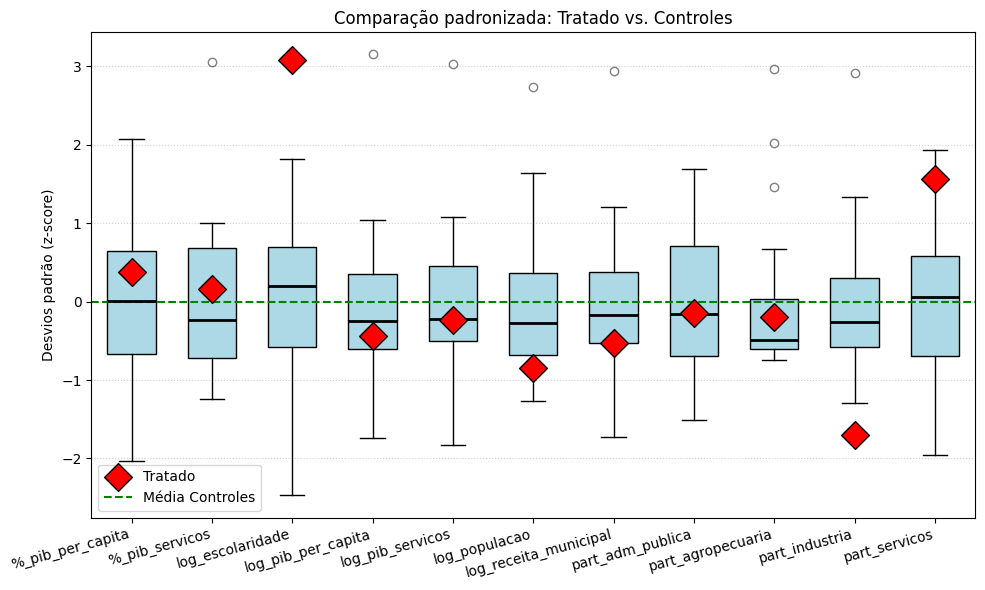

In [75]:
# ================================================================
# Boxplot padronizado (z-score) para todas as variáveis juntas
# ================================================================



# Preparar dados padronizados
dados_padronizados = []
tratado_padronizado = []
nomes_var = []

for var in variaveis:
    # Valores dos controles
    dados = df_match[df_match["tratamento"] == 0][var].dropna()
    if len(dados) == 0:
        continue
    # Padronizar
    dados_z = zscore(dados)
    dados_padronizados.append(dados_z)
    
    # Valor do tratado
    tratado_val = df_match[df_match["tratamento"] == 1][var].iloc[0]
    # Padronizar usando a média e desvio dos controles
    tratado_z = (tratado_val - dados.mean()) / dados.std()
    tratado_padronizado.append(tratado_z)
    
    nomes_var.append(var)

# Criar boxplots lado a lado
plt.figure(figsize=(10, 6))
bp = plt.boxplot(dados_padronizados, positions=range(len(nomes_var)), widths=0.6, patch_artist=True,
                 boxprops=dict(facecolor='lightblue'),
                 medianprops=dict(color='black', linewidth=2),
                 whiskerprops=dict(color='black'),
                 capprops=dict(color='black'),
                 flierprops=dict(marker='o', color='blue', alpha=0.5))

# Pontos do tratado
for i, z in enumerate(tratado_padronizado):
    plt.scatter(i, z, color='red', s=200, marker='D', 
                label='Tratado' if i == 0 else "", zorder=5, edgecolors='black')

# Linha de referência em 0 (média dos controles)
plt.axhline(y=0, color='green', linestyle='--', label='Média Controles')

plt.xticks(range(len(nomes_var)), nomes_var, rotation=15, ha='right')
plt.ylabel('Desvios padrão (z-score)')
plt.title('Comparação padronizada: Tratado vs. Controles')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

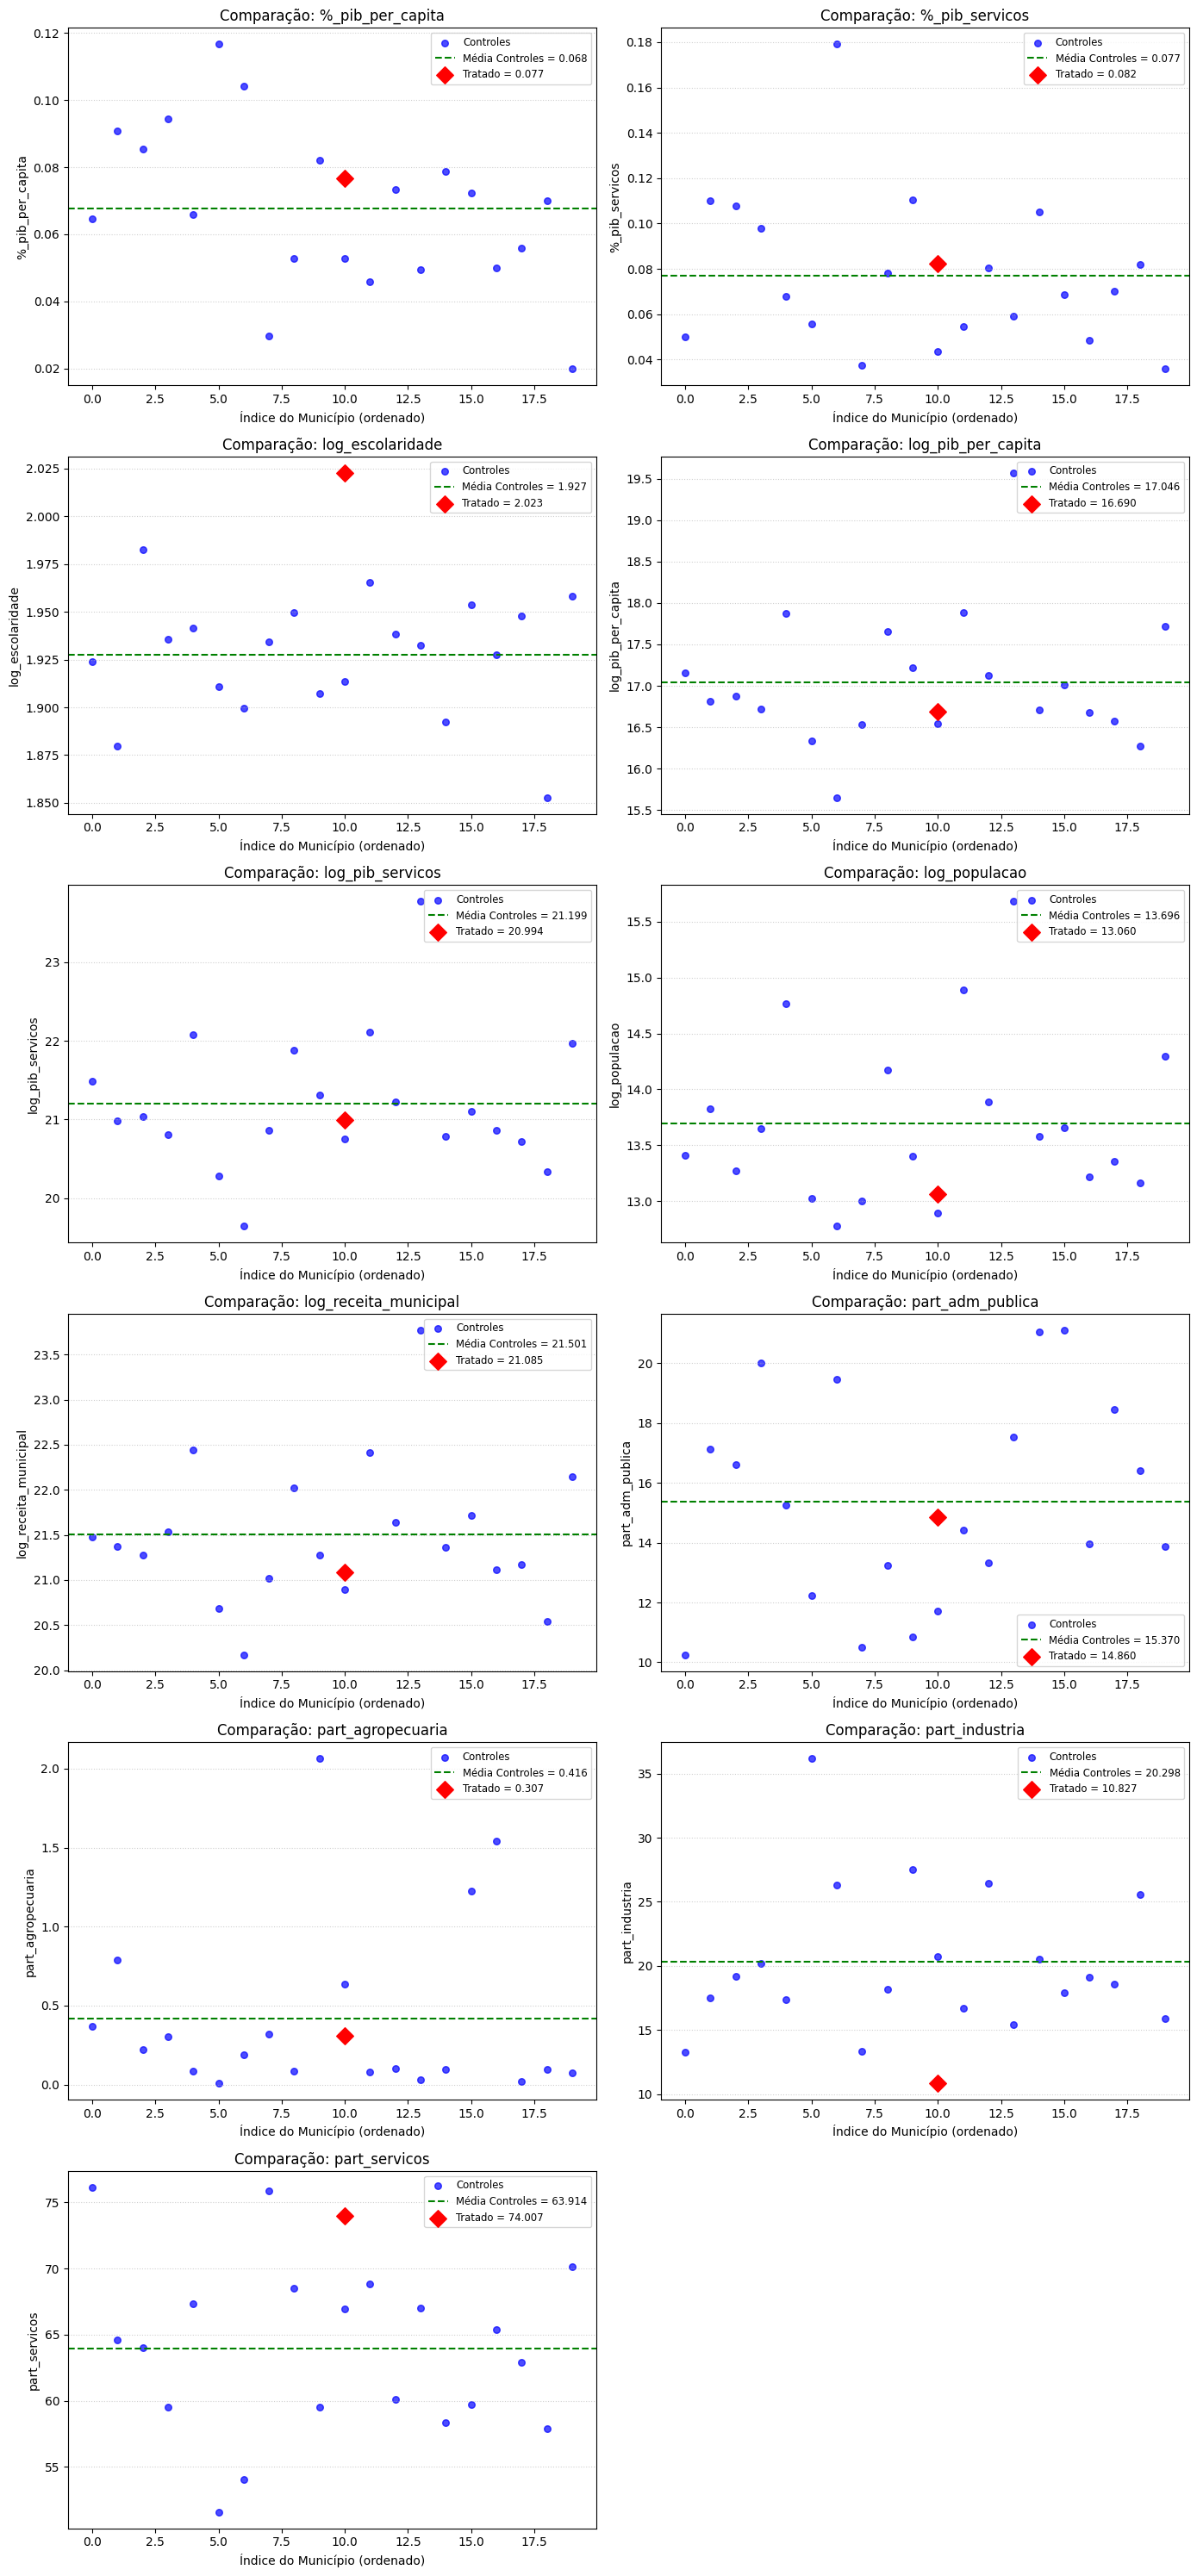

In [76]:
n_vars = len(variaveis)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

# Criar figura com subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
# Se houver apenas um subplot, axes não é um array 2D; ajustar
if n_vars == 1:
    axes = [axes]  # transforma em lista de 1 elemento
else:
    axes = axes.flatten()  # achata para facilitar iteração

# Para cada variável, gerar o gráfico no subplot correspondente
for i, var in enumerate(variaveis):
    ax = axes[i]

    # Extrair valores do tratado (primeiro município tratado) e dos controles
    tratado_val = df_match[df_match["tratamento"] == 1][var].iloc[0]
    controles_vals = df_match[df_match["tratamento"] == 0][var].values
    media_controles = controles_vals.mean()

    # Plotar pontos dos controles
    ax.scatter(range(len(controles_vals)), controles_vals,
               color='blue', label='Controles', s=30, alpha=0.7)

    # Linha horizontal da média dos controles
    ax.axhline(y=media_controles, color='green', linestyle='--',
               label=f'Média Controles = {media_controles:.3f}')

    # Ponto do tratado (destacado)
    ax.scatter(len(controles_vals)/2, tratado_val,
               color='red', s=100, marker='D',
               label=f'Tratado = {tratado_val:.3f}', zorder=5)

    # Personalização
    ax.set_xlabel('Índice do Município (ordenado)')
    ax.set_ylabel(var)
    ax.set_title(f'Comparação: {var}')
    ax.legend(fontsize='small')
    ax.grid(axis='y', linestyle=':', alpha=0.6)

# Esconder subplots não utilizados (caso número ímpar de variáveis)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Abaixo é possível analisar o propensity score do tratado e do grupo de controle

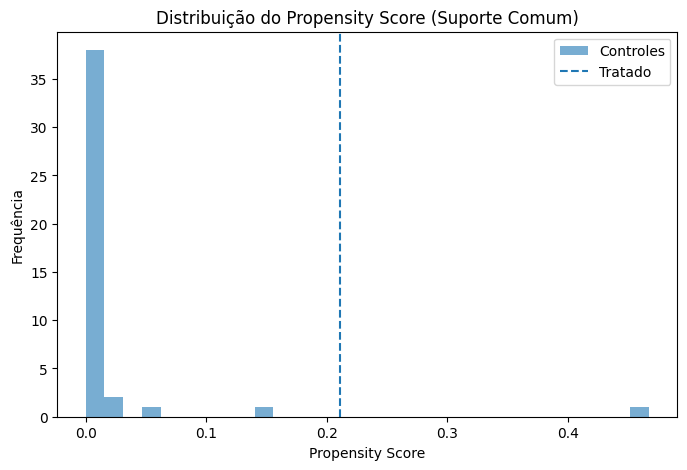

In [77]:

# separar grupos
tratado = df_matching_avg[df_matching_avg["tratamento"] == 1]
controles = df_matching_avg[df_matching_avg["tratamento"] == 0]

plt.figure(figsize=(8,5))

# distribuição controles
plt.hist(controles["propensity_score"], bins=30, alpha=0.6, label="Controles")

# linha do tratado
plt.axvline(tratado["propensity_score"].iloc[0], linestyle="--", label="Tratado")

plt.xlabel("Propensity Score")
plt.ylabel("Frequência")
plt.title("Distribuição do Propensity Score (Suporte Comum)")
plt.legend()

plt.show()

## Teste de tendências paralelas

A tendência paralela é testada tanto por coeficiente de interação, quanto por event study.  
Em ambos os casos, a hipótese nula de tendências paralelas se sustenta.

In [78]:
# ---------------------------------------------------------------
# 1. Painel completo: tratado + grupo de controle
# ---------------------------------------------------------------
ano_tratamento = ano_pre_tratamento + 1

ids_analise = grupo_controle["id_municipio"].tolist() + [municipio_tratado]

df_es = (
    df_matching[df_matching["id_municipio"].isin(ids_analise)]
    .copy()
    .reset_index(drop=True)
    .assign(
        tratado = lambda d: (d["id_municipio"] == municipio_tratado).astype(int),
        t_rel   = lambda d: d["ano"] - ano_tratamento,
    )
)

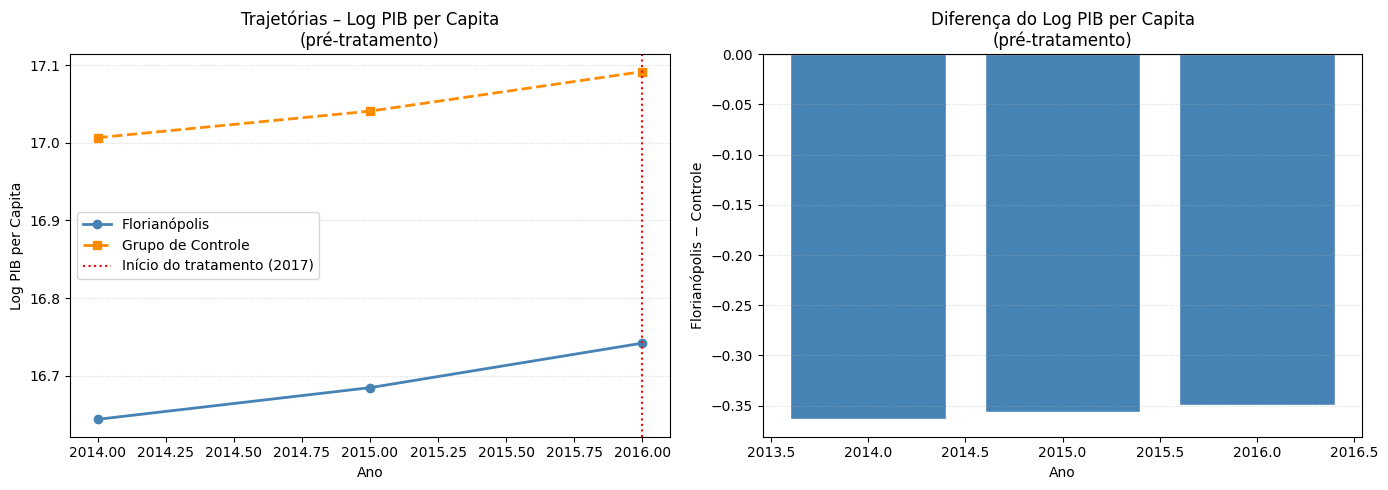

In [79]:
# ---------------------------------------------------------------
# 2. Visualização das trajetórias pré-tratamento
# ---------------------------------------------------------------

df_plot = (
    df_es[df_es["ano"] <= ano_pre_tratamento]
    .groupby(["ano", "tratado"])["log_pib_per_capita"]
    .mean()
    .reset_index()
    .pivot(index="ano", columns="tratado", values="log_pib_per_capita")
    .rename(columns={0: "Grupo de Controle", 1: "Florianópolis"})
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(df_plot["ano"], df_plot["Florianópolis"],
        marker="o", linewidth=2, label="Florianópolis", color="steelblue")
ax.plot(df_plot["ano"], df_plot["Grupo de Controle"],
        marker="s", linewidth=2, linestyle="--", label="Grupo de Controle", color="darkorange")
ax.axvline(ano_pre_tratamento, color="red", linestyle=":", linewidth=1.5,
           label=f"Início do tratamento ({ano_tratamento})")
ax.set(xlabel="Ano", ylabel="Log PIB per Capita",
       title="Trajetórias – Log PIB per Capita\n(pré-tratamento)")
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.5)

df_plot["diferenca"] = df_plot["Florianópolis"] - df_plot["Grupo de Controle"]
ax2 = axes[1]
ax2.bar(df_plot["ano"], df_plot["diferenca"], color="steelblue", edgecolor="white")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set(xlabel="Ano", ylabel="Florianópolis − Controle",
        title="Diferença do Log PIB per Capita\n(pré-tratamento)")
ax2.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

In [80]:
# ---------------------------------------------------------------
# 3. Teste formal: regressão pré-tratamento (H0: interação = 0)
# ---------------------------------------------------------------

df_pre = df_es[df_es["ano"] <= ano_pre_tratamento].copy()
df_pre["ano_c"] = df_pre["ano"] - df_pre["ano"].min()

modelo_tend = smf.ols(
    "log_pib_per_capita ~ ano_c * tratado", data=df_pre
).fit(cov_type="HC1")

coef = modelo_tend.params.get("ano_c:tratado", np.nan)
pval = modelo_tend.pvalues.get("ano_c:tratado", np.nan)
sinal = "✅ Não rejeitamos H0: tendências paralelas sustentadas." if pval > 0.05 \
        else "⚠️  Rejeitamos H0: evidência contra tendências paralelas."

print("=== Teste de Tendências Paralelas (Regressão) ===")
print(f"Coef. interação (ano × tratado): {coef:.6f}  |  p-valor: {pval:.4f}")
print(sinal)



=== Teste de Tendências Paralelas (Regressão) ===
Coef. interação (ano × tratado): 0.006542  |  p-valor: 0.9602
✅ Não rejeitamos H0: tendências paralelas sustentadas.


In [81]:
# ---------------------------------------------------------------
# 4. Dummies de evento e regressão com efeitos fixos
# ---------------------------------------------------------------

periodos_sem_base = [t for t in sorted(df_es["t_rel"].unique()) if t != -1]

interact_cols = []
for t in periodos_sem_base:
    col = f"it_{t + 100}"
    df_es[col] = df_es["tratado"] * (df_es["t_rel"] == t).astype(int)
    interact_cols.append((t, col))

X = pd.concat([
    df_es[[col for _, col in interact_cols]].astype(float),
    pd.get_dummies(df_es["id_municipio"], prefix="mun", drop_first=True).astype(int),
    pd.get_dummies(df_es["ano"],          prefix="ano", drop_first=True).astype(int),
], axis=1)

modelo_es = sm.OLS(
    df_es["log_pib_per_capita"].astype(float),
    sm.add_constant(X)
).fit(cov_type="cluster", cov_kwds={"groups": df_es["id_municipio"].values})



In [82]:
# ---------------------------------------------------------------
# 5. Extrair coeficientes e IC 95%
# ---------------------------------------------------------------

ci = modelo_es.conf_int()
df_coef = pd.DataFrame([
    {"t_rel"  : t,
     "coef"   : modelo_es.params.get(col, np.nan),
     "ci_low" : ci.loc[col, 0] if col in ci.index else np.nan,
     "ci_high": ci.loc[col, 1] if col in ci.index else np.nan,
     "pval"   : modelo_es.pvalues.get(col, np.nan)}
    for t, col in interact_cols
] + [{"t_rel": -1, "coef": 0., "ci_low": 0., "ci_high": 0., "pval": np.nan}]
).sort_values("t_rel").reset_index(drop=True)


In [83]:
# ---------------------------------------------------------------
# 6. Teste de Wald: coeficientes pré-tratamento = 0
# ---------------------------------------------------------------

pre_cols = [col for t, col in interact_cols if t < -1]

if pre_cols:
    R = np.zeros((len(pre_cols), len(modelo_es.params)))
    for i, col in enumerate(pre_cols):
        R[i, list(modelo_es.params.index).index(col)] = 1.0

    wald   = modelo_es.f_test(R)
    f_stat = float(np.atleast_1d(wald.statistic)[0])
    f_pval = float(wald.pvalue)

    sinal_wald = "✅ Tendências paralelas sustentadas." if f_pval > 0.05 \
                 else "⚠️  Evidência contra tendências paralelas."

    msg_wald = (
        f"Teste de Wald (pré-tratamento)\n"
        f"F = {f_stat:.3f}  |  p = {f_pval:.3f}\n"
        + ("✅ Tendências paralelas sustentadas (p > 0,05)" if f_pval > 0.05
           else "⚠️  Tendências NÃO paralelas (p ≤ 0,05)")
    )

    print(f"\n=== Teste de Wald (Event Study) ===")
    print(f"F-stat: {f_stat:.4f}  |  p-valor: {f_pval:.4f}  |  {sinal_wald}")
else:
    msg_wald = "Períodos pré-tratamento insuficientes\npara o teste de Wald"
    print("\n⚠️  Períodos pré-tratamento insuficientes para o teste de Wald.")


=== Teste de Wald (Event Study) ===
F-stat: 0.3871  |  p-valor: 0.6840  |  ✅ Tendências paralelas sustentadas.


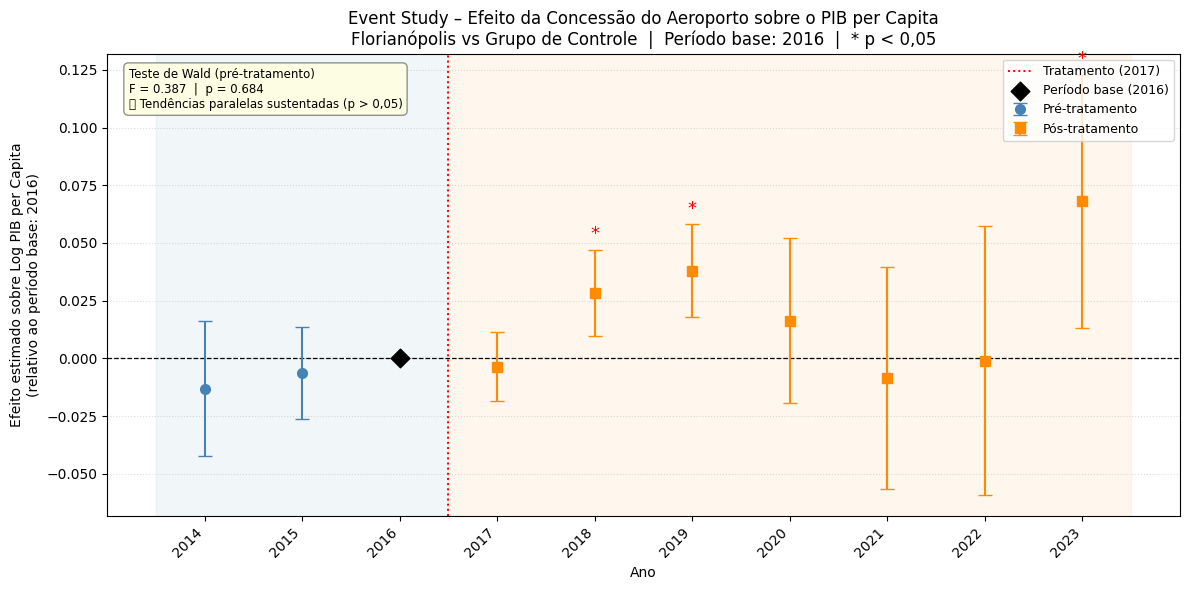

In [84]:
# ---------------------------------------------------------------
# 7. Gráfico do Event Study
# ---------------------------------------------------------------

pre = df_coef[df_coef["t_rel"] <  0]
pos = df_coef[df_coef["t_rel"] >= 0]

fig, ax = plt.subplots(figsize=(12, 6))

ax.axvspan(df_coef["t_rel"].min() - 0.5, -0.5,  alpha=0.07, color="steelblue")
ax.axvspan(-0.5, df_coef["t_rel"].max() + 0.5,  alpha=0.07, color="darkorange")
ax.axhline(0, color="black", linewidth=0.9, linestyle="--")
ax.axvline(-0.5, color="red", linewidth=1.4, linestyle=":",
           label=f"Tratamento ({ano_tratamento})")

for dados, fmt, cor, label in [
    (pre, "o", "steelblue",  "Pré-tratamento"),
    (pos, "s", "darkorange", "Pós-tratamento"),
]:
    ax.errorbar(
        dados["t_rel"], dados["coef"],
        yerr=[dados["coef"] - dados["ci_low"], dados["ci_high"] - dados["coef"]],
        fmt=fmt, color=cor, ecolor=cor, elinewidth=1.5,
        capsize=5, markersize=7, label=label,
    )

ax.scatter(-1, 0, color="black", zorder=5, s=90, marker="D", label=f"Período base ({ano_pre_tratamento})")

for _, row in df_coef.iterrows():
    if not np.isnan(row["pval"]) and row["pval"] < 0.05:
        ax.text(row["t_rel"], row["ci_high"] + 0.003, "*",
                ha="center", va="bottom", fontsize=13, color="red")

# Caixa com resultado do teste de Wald
ax.text(
    0.02, 0.97, msg_wald,
    transform=ax.transAxes,
    fontsize=8.5,
    verticalalignment="top",
    horizontalalignment="left",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow",
              edgecolor="gray", alpha=0.85),
)

anos_eixo = sorted(df_coef["t_rel"].unique())
ax.set_xticks(anos_eixo)
ax.set_xticklabels([str(ano_tratamento + t) for t in anos_eixo], rotation=45, ha="right")
ax.set(xlabel="Ano",
       ylabel=f"Efeito estimado sobre Log PIB per Capita\n(relativo ao período base: {ano_pre_tratamento})",
       title=f"Event Study – Efeito da Concessão do Aeroporto sobre o PIB per Capita\n"
             f"Florianópolis vs Grupo de Controle  |  Período base: {ano_pre_tratamento}  |  * p < 0,05")
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.45)
plt.tight_layout()
plt.show()

In [85]:
# ---------------------------------------------------------------
# 8. Tabela-resumo dos efeitos pós-tratamento
# ---------------------------------------------------------------

def sig(p):
    if np.isnan(p): return ""
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""

resumo = (
    df_coef[df_coef["t_rel"] >= 0]
    .assign(ano=lambda d: ano_tratamento + d["t_rel"],
            sig=lambda d: d["pval"].apply(sig))
    .rename(columns={"t_rel": "t", "coef": "Coef.",
                     "ci_low": "IC 2,5%", "ci_high": "IC 97,5%",
                     "pval": "p-valor", "sig": "Sig."})
    [["ano", "t", "Coef.", "IC 2,5%", "IC 97,5%", "p-valor", "Sig."]]
)
print("\n=== Efeitos pós-tratamento ===")
print(resumo.to_string(index=False))


=== Efeitos pós-tratamento ===
 ano  t     Coef.   IC 2,5%  IC 97,5%  p-valor Sig.
2017  0 -0.003655 -0.018679  0.011369 0.633475     
2018  1  0.028189  0.009544  0.046834 0.003044  ***
2019  2  0.038042  0.018064  0.058021 0.000190  ***
2020  3  0.016276 -0.019563  0.052115 0.373414     
2021  4 -0.008502 -0.056632  0.039628 0.729181     
2022  5 -0.000946 -0.059191  0.057298 0.974593     
2023  6  0.068020  0.013134  0.122905 0.015141   **


## Event Study com covariáveis de controle (versão até 2023)

Reestimação do Event Study incluindo covariáveis time-varying como controles diretos na regressão TWFE.  
As covariáveis **não** são interagidas com as dummies de evento — entram apenas para absorver variação
observável que poderia confundir os coeficientes.

**Como configurar (célula seguinte):**
- `ano_final_es` — define o último ano incluído no painel do event study com controles
- `excluir_manualmente_es` — lista de covariáveis a excluir mesmo que sejam válidas para o período

O código detecta automaticamente quais variáveis numéricas possuem cobertura completa
(sem NaN nem Inf) para todos os municípios e anos do painel selecionado,
usando a mesma lógica de `detectar_variaveis_com_missing` do DiD.

**Especificação estimada:**
$$
\ln(PIBpc_{it}) = \alpha_i + \gamma_t
+ \sum_{k \neq -1} \delta_k \cdot \mathbf{1}[t{-}t^*=k] \cdot Treat_i
+ X_{it}'\beta + \varepsilon_{it}
$$
onde $\alpha_i$ = EF município, $\gamma_t$ = EF ano, $X_{it}$ = covariáveis
e $k=-1$ (ano pré-tratamento) é o período base omitido.


In [86]:
# ================================================================
# CONFIGURAÇÃO — Event Study com Covariáveis
# ================================================================
# Edite apenas este bloco antes de executar as células seguintes.

# ── Variável dependente ──────────────────────────────────────────
var_dep_es = "log_pib_per_capita"

# ── Ano final do painel ──────────────────────────────────────────
# Use 2021 para evitar problemas de cobertura dos dados setoriais;
# use 2023 para o horizonte completo do PIB per capita.
ano_final_es = 2023

# ── Exclusão manual de covariáveis ───────────────────────────────
# Variáveis que NÃO devem entrar como controles mesmo sem missing.
# Remova ou adicione itens conforme necessário.
excluir_manualmente_es = [
    "%_pib_per_capita",   # taxa de crescimento da variável dependente
    "%_pib_servicos",     # taxa de crescimento do PIB de serviços
    "part_adm_publica",   # participação da adm. pública (potencialmente endógena)
    "log_pib_servicos",   # variável dependente alternativa
]


In [87]:
# ================================================================
# SEÇÃO 1: Função para detectar variáveis com missing no período
# ================================================================

def detectar_variaveis_com_missing(df, ids_municipios, anos, excluir_fixo=None):
    """
    Retorna lista de variáveis numéricas que possuem NaN ou Inf
    para os municípios e anos informados.

    Parâmetros
    ----------
    df             : DataFrame com o painel completo
    ids_municipios : lista com ids do tratado + controles
    anos           : lista com os dois anos do DiD [ano_pre, ano_pos]
    excluir_fixo   : lista de colunas a ignorar na busca

    Retorna
    -------
    lista de nomes de colunas com ao menos um valor inválido
    """
    if excluir_fixo is None:
        excluir_fixo = []

    df_janela = df[
        (df["id_municipio"].isin(ids_municipios)) &
        (df["ano"].isin(anos))
    ].copy()

    numericas = (
        df_janela
        .select_dtypes(include="number")
        .columns
        .difference(excluir_fixo)
        .tolist()
    )

    variaveis_com_missing = [
        col for col in numericas
        if df_janela[col].isna().any() or np.isinf(df_janela[col]).any()
    ]

    return variaveis_com_missing

In [88]:
# ================================================================
# 1. Filtrar painel até ano_final_es e detectar covariáveis válidas
# ================================================================
# IMPORTANTE: as dummies de evento (interact_cols) foram criadas na
# célula 102 com base no painel COMPLETO (todos os anos disponíveis).
# Quando ano_final_es < ano máximo do painel, o painel truncado
# não contém alguns dos anos para os quais as dummies foram criadas,
# gerando colunas constantes (apenas zeros) que causam multicolinearidade
# e distorcem os coeficientes pré-tratamento — e portanto o Teste de Wald.
#
# Solução: REGERAR interact_cols_ctrl exclusivamente a partir do painel
# truncado df_es_ctrl, garantindo que cada dummy tenha variação real.

ids_es     = grupo_controle["id_municipio"].tolist() + [municipio_tratado]
df_es_ctrl = df_es[df_es["ano"] <= ano_final_es].copy()
anos_es    = sorted(df_es_ctrl["ano"].unique().tolist())

# ── Remontar dummies de evento para o painel truncado ────────────
# Períodos relativos disponíveis no painel truncado, excluindo a base (t=-1)
periodos_ctrl = [
    t for t in sorted(df_es_ctrl["t_rel"].unique()) if t != -1
]

# Remover colunas it_* antigas que possam ter ficado de execuções anteriores
cols_it_antigas = [c for c in df_es_ctrl.columns if c.startswith("it_")]
df_es_ctrl = df_es_ctrl.drop(columns=cols_it_antigas, errors="ignore")

interact_cols_ctrl = []
for t in periodos_ctrl:
    col = f"it_ctrl_{t + 100}"   # prefixo distinto para não colidir com interact_cols
    df_es_ctrl[col] = (
        df_es_ctrl["tratado"] * (df_es_ctrl["t_rel"] == t).astype(int)
    )
    interact_cols_ctrl.append((t, col))

# ── Detectar covariáveis válidas ─────────────────────────────────
cols_excluir_cov = (
    ["tratamento", "tratado", "ano", "id_municipio", "t_rel", var_dep_es]
    + excluir_manualmente_es
    + [col for _, col in interact_cols_ctrl]
    + [col for _, col in interact_cols]    # também excluir dummies do painel completo
)

numericas_es = (
    df_es_ctrl
    .select_dtypes(include="number")
    .columns
    .difference(cols_excluir_cov)
    .tolist()
)

missing_es = detectar_variaveis_com_missing(
    df_es_ctrl,
    ids_municipios=ids_es,
    anos=anos_es,
    excluir_fixo=cols_excluir_cov,
)

covariaveis_es_validas = [c for c in numericas_es if c not in missing_es]

# ── Relatório ────────────────────────────────────────────────────
print(f"Variável dependente : {var_dep_es}")
print(f"Painel              : {anos_es[0]} – {anos_es[-1]}  ({len(anos_es)} anos)")
print(f"Municípios          : {len(ids_es)}  ({len(ids_es)-1} controles + 1 tratado)")
print(f"Períodos de evento  : {[ano_tratamento + t for t in periodos_ctrl]}")
print()
print(f"Candidatas avaliadas ({len(numericas_es)}): {numericas_es}")
print()
if missing_es:
    print(f"⚠️  Excluídas por missing/Inf ({len(missing_es)}): {missing_es}")
else:
    print("✅ Nenhuma candidata com missing/Inf.")
if excluir_manualmente_es:
    print(f"🚫 Excluídas manualmente ({len(excluir_manualmente_es)}): {excluir_manualmente_es}")
print()
print(f"✅ Covariáveis incluídas no modelo ({len(covariaveis_es_validas)}):")
for c in covariaveis_es_validas:
    print(f"   • {c}")


Variável dependente : log_pib_per_capita
Painel              : 2014 – 2023  (10 anos)
Municípios          : 21  (20 controles + 1 tratado)
Períodos de evento  : [np.int64(2014), np.int64(2015), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Candidatas avaliadas (6): ['log_escolaridade', 'log_populacao', 'log_receita_municipal', 'part_agropecuaria', 'part_industria', 'part_servicos']

⚠️  Excluídas por missing/Inf (3): ['part_agropecuaria', 'part_industria', 'part_servicos']
🚫 Excluídas manualmente (4): ['%_pib_per_capita', '%_pib_servicos', 'part_adm_publica', 'log_pib_servicos']

✅ Covariáveis incluídas no modelo (3):
   • log_escolaridade
   • log_populacao
   • log_receita_municipal


In [89]:
# ================================================================
# 2. Estimar TWFE com covariáveis — painel até ano_final_es
# ================================================================
# Usa interact_cols_ctrl gerado na célula anterior a partir do painel
# truncado — todas as dummies têm variação real neste subpainel.

X_ctrl = pd.concat([
    df_es_ctrl[[col for _, col in interact_cols_ctrl]].astype(float),
    df_es_ctrl[covariaveis_es_validas].astype(float),
    pd.get_dummies(df_es_ctrl["id_municipio"], prefix="mun", drop_first=True).astype(int),
    pd.get_dummies(df_es_ctrl["ano"],          prefix="ano", drop_first=True).astype(int),
], axis=1)

X_ctrl   = X_ctrl.loc[:, X_ctrl.nunique() > 1]   # remove colunas constantes
X_ctrl   = X_ctrl.dropna()
y_ctrl   = df_es_ctrl[var_dep_es].astype(float).loc[X_ctrl.index]
grp_ctrl = df_es_ctrl["id_municipio"].loc[X_ctrl.index].values

modelo_es_ctrl = sm.OLS(
    y_ctrl, sm.add_constant(X_ctrl)
).fit(cov_type="cluster", cov_kwds={"groups": grp_ctrl})

print(f"Modelo estimado com sucesso.")
print(f"N = {int(modelo_es_ctrl.nobs):,}  |  R² = {modelo_es_ctrl.rsquared:.4f}")
print(f"Covariáveis: {covariaveis_es_validas}")
print(f"Período: {anos_es[0]} – {anos_es[-1]}")


Modelo estimado com sucesso.
N = 210  |  R² = 0.9964
Covariáveis: ['log_escolaridade', 'log_populacao', 'log_receita_municipal']
Período: 2014 – 2023


In [90]:
# ================================================================
# 3. Extrair coeficientes, IC 95% e Teste de Wald
# ================================================================

ci_ctrl = modelo_es_ctrl.conf_int()

df_coef_ctrl = pd.DataFrame([
    {
        "t_rel"  : t,
        "coef"   : modelo_es_ctrl.params.get(col, np.nan),
        "ci_low" : ci_ctrl.loc[col, 0] if col in ci_ctrl.index else np.nan,
        "ci_high": ci_ctrl.loc[col, 1] if col in ci_ctrl.index else np.nan,
        "pval"   : modelo_es_ctrl.pvalues.get(col, np.nan),
    }
    for t, col in interact_cols_ctrl
] + [{"t_rel": -1, "coef": 0., "ci_low": 0., "ci_high": 0., "pval": np.nan}]
).sort_values("t_rel").reset_index(drop=True)

# ── Teste de Wald: δ_k = 0 para todo k < -1 ──────────────────────
# Testa apenas períodos pré-tratamento com mais de 1 ano antes da base,
# usando as dummies do painel truncado (sem risco de colunas constantes).
pre_cols_ctrl = [col for t, col in interact_cols_ctrl if t < -1]

if pre_cols_ctrl:
    R_ctrl = np.zeros((len(pre_cols_ctrl), len(modelo_es_ctrl.params)))
    for i, col in enumerate(pre_cols_ctrl):
        R_ctrl[i, list(modelo_es_ctrl.params.index).index(col)] = 1.0

    wald_ctrl   = modelo_es_ctrl.f_test(R_ctrl)
    f_stat_ctrl = float(np.atleast_1d(wald_ctrl.statistic)[0])
    f_pval_ctrl = float(wald_ctrl.pvalue)

    msg_wald_ctrl = (
        f"Teste de Wald (pré-tratamento, com controles)\n"
        f"F = {f_stat_ctrl:.3f}  |  p = {f_pval_ctrl:.3f}\n"
        + ("✅ Tendências paralelas sustentadas (p > 0,05)"
           if f_pval_ctrl > 0.05
           else "⚠️  Tendências NÃO paralelas (p ≤ 0,05)")
    )
    print("=== Teste de Wald (Event Study com Controles) ===")
    print(f"F-stat: {f_stat_ctrl:.4f}  |  p-valor: {f_pval_ctrl:.4f}")
    print(msg_wald_ctrl)
else:
    msg_wald_ctrl = "Períodos pré-tratamento insuficientes\npara o teste de Wald"
    print("⚠️  Períodos pré-tratamento insuficientes para o teste de Wald.")


=== Teste de Wald (Event Study com Controles) ===
F-stat: 0.0497  |  p-valor: 0.9517
Teste de Wald (pré-tratamento, com controles)
F = 0.050  |  p = 0.952
✅ Tendências paralelas sustentadas (p > 0,05)


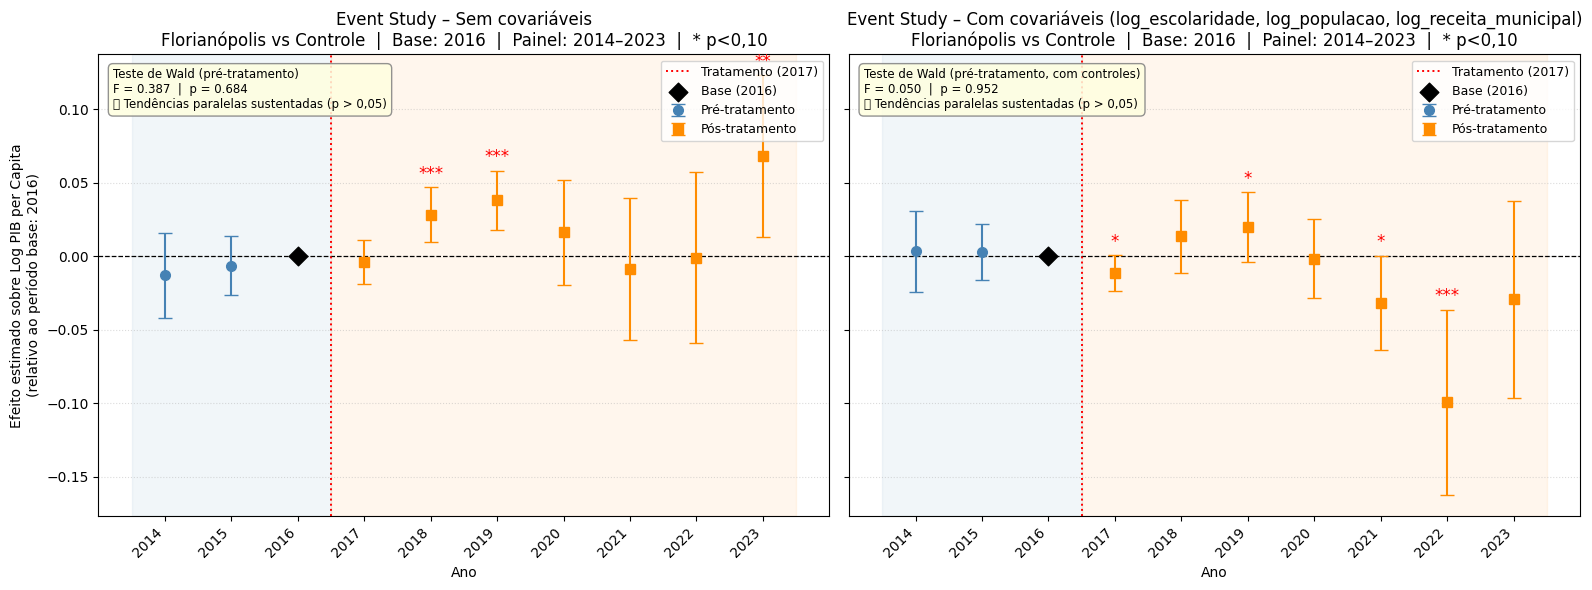

In [91]:
# ================================================================
# 4. Gráfico comparativo: Event Study sem vs. com covariáveis
# ================================================================
# O painel da esquerda usa df_coef (todos os anos disponíveis, sem controles).
# O painel da direita usa df_coef_ctrl (painel até ano_final_es, com controles).

# Restringe df_coef ao mesmo horizonte temporal para comparação justa
df_coef_base = df_coef[df_coef["t_rel"].apply(
    lambda t: (ano_tratamento + t) <= ano_final_es
)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

anos_eixo_ctrl = sorted(df_coef_ctrl["t_rel"].unique())

configs = [
    (axes[0], df_coef_base,  msg_wald,      "Sem covariáveis"),
    (axes[1], df_coef_ctrl,  msg_wald_ctrl,
     f"Com covariáveis ({', '.join(covariaveis_es_validas)})"),
]

for ax, df_c_full, msg, titulo in configs:
    df_c_pre = df_c_full[df_c_full["t_rel"] <  0]
    df_c_pos = df_c_full[df_c_full["t_rel"] >= 0]

    ax.axvspan(min(anos_eixo_ctrl) - 0.5, -0.5, alpha=0.07, color="steelblue")
    ax.axvspan(-0.5, max(anos_eixo_ctrl) + 0.5, alpha=0.07, color="darkorange")
    ax.axhline(0, color="black", linewidth=0.9, linestyle="--")
    ax.axvline(-0.5, color="red", linewidth=1.4, linestyle=":",
               label=f"Tratamento ({ano_tratamento})")

    for dados, fmt, cor, label in [
        (df_c_pre, "o", "steelblue",  "Pré-tratamento"),
        (df_c_pos, "s", "darkorange", "Pós-tratamento"),
    ]:
        ax.errorbar(
            dados["t_rel"], dados["coef"],
            yerr=[dados["coef"] - dados["ci_low"],
                  dados["ci_high"] - dados["coef"]],
            fmt=fmt, color=cor, ecolor=cor,
            elinewidth=1.5, capsize=5, markersize=7, label=label,
        )

    ax.scatter(-1, 0, color="black", zorder=5, s=90,
               marker="D", label=f"Base ({ano_pre_tratamento})")

    for _, row in df_c_full.iterrows():
        if not np.isnan(row["pval"]) and row["pval"] < 0.1:
            stars = "***" if row["pval"] < 0.01 else "**" if row["pval"] < 0.05 else "*"
            ax.text(row["t_rel"], row["ci_high"] + 0.003, stars,
                    ha="center", va="bottom", fontsize=12, color="red")

    ax.text(
        0.02, 0.97, msg,
        transform=ax.transAxes, fontsize=8.5,
        verticalalignment="top", horizontalalignment="left",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow",
                  edgecolor="gray", alpha=0.85),
    )

    ax.set_xticks(anos_eixo_ctrl)
    ax.set_xticklabels(
        [str(ano_tratamento + t) for t in anos_eixo_ctrl],
        rotation=45, ha="right"
    )
    ax.set_xlabel("Ano")
    ax.set_title(
        f"Event Study – {titulo}\n"
        f"Florianópolis vs Controle  |  Base: {ano_pre_tratamento}  "
        f"|  Painel: {anos_es[0]}–{anos_es[-1]}  |  * p<0,10"
    )
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(axis="y", linestyle=":", alpha=0.45)

axes[0].set_ylabel(
    f"Efeito estimado sobre Log PIB per Capita\n"
    f"(relativo ao período base: {ano_pre_tratamento})"
)
plt.tight_layout()
plt.show()


In [92]:
# ================================================================
# 5. Tabela de efeitos pós-tratamento — modelo com covariáveis
# ================================================================

def sig(p):
    if np.isnan(p): return ""
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""

resumo_ctrl = (
    df_coef_ctrl[df_coef_ctrl["t_rel"] >= 0]
    .assign(
        ano        = lambda d: ano_tratamento + d["t_rel"],
        sig        = lambda d: d["pval"].apply(sig),
        efeito_pct = lambda d: (np.exp(d["coef"]) - 1) * 100,
    )
    .rename(columns={
        "t_rel"     : "t",
        "coef"      : "Coef.",
        "ci_low"    : "IC 2,5%",
        "ci_high"   : "IC 97,5%",
        "pval"      : "p-valor",
        "sig"       : "Sig.",
        "efeito_pct": "Efeito (%)",
    })
    [["ano", "t", "Coef.", "IC 2,5%", "IC 97,5%", "Efeito (%)", "p-valor", "Sig."]]
)

print(f"=== Efeitos pós-tratamento — com covariáveis ===")
print(f"Painel   : {anos_es[0]} – {anos_es[-1]}")
print(f"Covariáveis: {covariaveis_es_validas}")
print(resumo_ctrl.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nNota: Erros clusterizados por município. * p<0,10  ** p<0,05  *** p<0,01")


=== Efeitos pós-tratamento — com covariáveis ===
Painel   : 2014 – 2023
Covariáveis: ['log_escolaridade', 'log_populacao', 'log_receita_municipal']
 ano  t   Coef.  IC 2,5%  IC 97,5%  Efeito (%)  p-valor Sig.
2017  0 -0.0114  -0.0236    0.0008     -1.1353   0.0673    *
2018  1  0.0135  -0.0116    0.0385      1.3547   0.2928     
2019  2  0.0199  -0.0036    0.0434      2.0097   0.0974    *
2020  3 -0.0017  -0.0285    0.0250     -0.1711   0.9002     
2021  4 -0.0317  -0.0639    0.0005     -3.1209   0.0536    *
2022  5 -0.0993  -0.1623   -0.0363     -9.4529   0.0020  ***
2023  6 -0.0294  -0.0963    0.0375     -2.8927   0.3898     

Nota: Erros clusterizados por município. * p<0,10  ** p<0,05  *** p<0,01


In [93]:
# ================================================================
# 6. Coeficientes das covariáveis no modelo com controles
# ================================================================

ci_ctrl_full = modelo_es_ctrl.conf_int()

linhas_cov_es = []
for var in covariaveis_es_validas:
    if var not in modelo_es_ctrl.params.index:
        continue
    linhas_cov_es.append({
        "Covariável": var,
        "Coef."     : float(modelo_es_ctrl.params[var]),
        "Erro Pad." : float(modelo_es_ctrl.bse[var]),
        "p-valor"   : float(modelo_es_ctrl.pvalues[var]),
        "IC 2,5%"   : float(ci_ctrl_full.loc[var, 0]),
        "IC 97,5%"  : float(ci_ctrl_full.loc[var, 1]),
        "Sig."      : sig(float(modelo_es_ctrl.pvalues[var])),
    })

df_cov_es = pd.DataFrame(linhas_cov_es)
print("=== Covariáveis no Event Study com Controles ===")
print(df_cov_es.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nN = {int(modelo_es_ctrl.nobs):,}  |  R² = {modelo_es_ctrl.rsquared:.4f}  "
      f"|  EF município: sim  |  EF ano: sim")


=== Covariáveis no Event Study com Controles ===
           Covariável  Coef.  Erro Pad.  p-valor  IC 2,5%  IC 97,5% Sig.
     log_escolaridade 0.3441     0.2434   0.1573  -0.1328    0.8211     
        log_populacao 0.7528     0.2423   0.0019   0.2779    1.2278  ***
log_receita_municipal 0.1678     0.1676   0.3170  -0.1608    0.4963     

N = 210  |  R² = 0.9964  |  EF município: sim  |  EF ano: sim


## Event Study com covariáveis de controle (versão até 2021)


In [94]:
# ================================================================
# CONFIGURAÇÃO — Event Study com Covariáveis
# ================================================================
# Edite apenas este bloco antes de executar as células seguintes.

# ── Variável dependente ──────────────────────────────────────────
var_dep_es = "log_pib_per_capita"

# ── Ano final do painel ──────────────────────────────────────────
# Use 2021 para evitar problemas de cobertura dos dados setoriais;
# use 2023 para o horizonte completo do PIB per capita.
ano_final_es = 2021

# ── Exclusão manual de covariáveis ───────────────────────────────
# Variáveis que NÃO devem entrar como controles mesmo sem missing.
# Remova ou adicione itens conforme necessário.
excluir_manualmente_es = [
    "%_pib_per_capita",   # taxa de crescimento da variável dependente
    "%_pib_servicos",     # taxa de crescimento do PIB de serviços
    "part_adm_publica",   # participação da adm. pública (potencialmente endógena)
    "log_pib_servicos",   # variável dependente alternativa
]


In [95]:
# ================================================================
# SEÇÃO 1: Função para detectar variáveis com missing no período
# ================================================================

def detectar_variaveis_com_missing(df, ids_municipios, anos, excluir_fixo=None):
    """
    Retorna lista de variáveis numéricas que possuem NaN ou Inf
    para os municípios e anos informados.

    Parâmetros
    ----------
    df             : DataFrame com o painel completo
    ids_municipios : lista com ids do tratado + controles
    anos           : lista com os dois anos do DiD [ano_pre, ano_pos]
    excluir_fixo   : lista de colunas a ignorar na busca

    Retorna
    -------
    lista de nomes de colunas com ao menos um valor inválido
    """
    if excluir_fixo is None:
        excluir_fixo = []

    df_janela = df[
        (df["id_municipio"].isin(ids_municipios)) &
        (df["ano"].isin(anos))
    ].copy()

    numericas = (
        df_janela
        .select_dtypes(include="number")
        .columns
        .difference(excluir_fixo)
        .tolist()
    )

    variaveis_com_missing = [
        col for col in numericas
        if df_janela[col].isna().any() or np.isinf(df_janela[col]).any()
    ]

    return variaveis_com_missing

In [96]:
# ================================================================
# 1. Filtrar painel até ano_final_es e detectar covariáveis válidas
# ================================================================
# IMPORTANTE: as dummies de evento (interact_cols) foram criadas na
# célula 102 com base no painel COMPLETO (todos os anos disponíveis).
# Quando ano_final_es < ano máximo do painel, o painel truncado
# não contém alguns dos anos para os quais as dummies foram criadas,
# gerando colunas constantes (apenas zeros) que causam multicolinearidade
# e distorcem os coeficientes pré-tratamento — e portanto o Teste de Wald.
#
# Solução: REGERAR interact_cols_ctrl exclusivamente a partir do painel
# truncado df_es_ctrl, garantindo que cada dummy tenha variação real.

ids_es     = grupo_controle["id_municipio"].tolist() + [municipio_tratado]
df_es_ctrl = df_es[df_es["ano"] <= ano_final_es].copy()
anos_es    = sorted(df_es_ctrl["ano"].unique().tolist())

# ── Remontar dummies de evento para o painel truncado ────────────
# Períodos relativos disponíveis no painel truncado, excluindo a base (t=-1)
periodos_ctrl = [
    t for t in sorted(df_es_ctrl["t_rel"].unique()) if t != -1
]

# Remover colunas it_* antigas que possam ter ficado de execuções anteriores
cols_it_antigas = [c for c in df_es_ctrl.columns if c.startswith("it_")]
df_es_ctrl = df_es_ctrl.drop(columns=cols_it_antigas, errors="ignore")

interact_cols_ctrl = []
for t in periodos_ctrl:
    col = f"it_ctrl_{t + 100}"   # prefixo distinto para não colidir com interact_cols
    df_es_ctrl[col] = (
        df_es_ctrl["tratado"] * (df_es_ctrl["t_rel"] == t).astype(int)
    )
    interact_cols_ctrl.append((t, col))

# ── Detectar covariáveis válidas ─────────────────────────────────
cols_excluir_cov = (
    ["tratamento", "tratado", "ano", "id_municipio", "t_rel", var_dep_es]
    + excluir_manualmente_es
    + [col for _, col in interact_cols_ctrl]
    + [col for _, col in interact_cols]    # também excluir dummies do painel completo
)

numericas_es = (
    df_es_ctrl
    .select_dtypes(include="number")
    .columns
    .difference(cols_excluir_cov)
    .tolist()
)

missing_es = detectar_variaveis_com_missing(
    df_es_ctrl,
    ids_municipios=ids_es,
    anos=anos_es,
    excluir_fixo=cols_excluir_cov,
)

covariaveis_es_validas = [c for c in numericas_es if c not in missing_es]

# ── Relatório ────────────────────────────────────────────────────
print(f"Variável dependente : {var_dep_es}")
print(f"Painel              : {anos_es[0]} – {anos_es[-1]}  ({len(anos_es)} anos)")
print(f"Municípios          : {len(ids_es)}  ({len(ids_es)-1} controles + 1 tratado)")
print(f"Períodos de evento  : {[ano_tratamento + t for t in periodos_ctrl]}")
print()
print(f"Candidatas avaliadas ({len(numericas_es)}): {numericas_es}")
print()
if missing_es:
    print(f"⚠️  Excluídas por missing/Inf ({len(missing_es)}): {missing_es}")
else:
    print("✅ Nenhuma candidata com missing/Inf.")
if excluir_manualmente_es:
    print(f"🚫 Excluídas manualmente ({len(excluir_manualmente_es)}): {excluir_manualmente_es}")
print()
print(f"✅ Covariáveis incluídas no modelo ({len(covariaveis_es_validas)}):")
for c in covariaveis_es_validas:
    print(f"   • {c}")


Variável dependente : log_pib_per_capita
Painel              : 2014 – 2021  (8 anos)
Municípios          : 21  (20 controles + 1 tratado)
Períodos de evento  : [np.int64(2014), np.int64(2015), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]

Candidatas avaliadas (6): ['log_escolaridade', 'log_populacao', 'log_receita_municipal', 'part_agropecuaria', 'part_industria', 'part_servicos']

✅ Nenhuma candidata com missing/Inf.
🚫 Excluídas manualmente (4): ['%_pib_per_capita', '%_pib_servicos', 'part_adm_publica', 'log_pib_servicos']

✅ Covariáveis incluídas no modelo (6):
   • log_escolaridade
   • log_populacao
   • log_receita_municipal
   • part_agropecuaria
   • part_industria
   • part_servicos


In [97]:
# ================================================================
# 2. Estimar TWFE com covariáveis — painel até ano_final_es
# ================================================================
# Usa interact_cols_ctrl gerado na célula anterior a partir do painel
# truncado — todas as dummies têm variação real neste subpainel.

X_ctrl = pd.concat([
    df_es_ctrl[[col for _, col in interact_cols_ctrl]].astype(float),
    df_es_ctrl[covariaveis_es_validas].astype(float),
    pd.get_dummies(df_es_ctrl["id_municipio"], prefix="mun", drop_first=True).astype(int),
    pd.get_dummies(df_es_ctrl["ano"],          prefix="ano", drop_first=True).astype(int),
], axis=1)

X_ctrl   = X_ctrl.loc[:, X_ctrl.nunique() > 1]   # remove colunas constantes
X_ctrl   = X_ctrl.dropna()
y_ctrl   = df_es_ctrl[var_dep_es].astype(float).loc[X_ctrl.index]
grp_ctrl = df_es_ctrl["id_municipio"].loc[X_ctrl.index].values

modelo_es_ctrl = sm.OLS(
    y_ctrl, sm.add_constant(X_ctrl)
).fit(cov_type="cluster", cov_kwds={"groups": grp_ctrl})

print(f"Modelo estimado com sucesso.")
print(f"N = {int(modelo_es_ctrl.nobs):,}  |  R² = {modelo_es_ctrl.rsquared:.4f}")
print(f"Covariáveis: {covariaveis_es_validas}")
print(f"Período: {anos_es[0]} – {anos_es[-1]}")


Modelo estimado com sucesso.
N = 168  |  R² = 0.9989
Covariáveis: ['log_escolaridade', 'log_populacao', 'log_receita_municipal', 'part_agropecuaria', 'part_industria', 'part_servicos']
Período: 2014 – 2021


In [98]:
# ================================================================
# 3. Extrair coeficientes, IC 95% e Teste de Wald
# ================================================================

ci_ctrl = modelo_es_ctrl.conf_int()

df_coef_ctrl = pd.DataFrame([
    {
        "t_rel"  : t,
        "coef"   : modelo_es_ctrl.params.get(col, np.nan),
        "ci_low" : ci_ctrl.loc[col, 0] if col in ci_ctrl.index else np.nan,
        "ci_high": ci_ctrl.loc[col, 1] if col in ci_ctrl.index else np.nan,
        "pval"   : modelo_es_ctrl.pvalues.get(col, np.nan),
    }
    for t, col in interact_cols_ctrl
] + [{"t_rel": -1, "coef": 0., "ci_low": 0., "ci_high": 0., "pval": np.nan}]
).sort_values("t_rel").reset_index(drop=True)

# ── Teste de Wald: δ_k = 0 para todo k < -1 ──────────────────────
# Testa apenas períodos pré-tratamento com mais de 1 ano antes da base,
# usando as dummies do painel truncado (sem risco de colunas constantes).
pre_cols_ctrl = [col for t, col in interact_cols_ctrl if t < -1]

if pre_cols_ctrl:
    R_ctrl = np.zeros((len(pre_cols_ctrl), len(modelo_es_ctrl.params)))
    for i, col in enumerate(pre_cols_ctrl):
        R_ctrl[i, list(modelo_es_ctrl.params.index).index(col)] = 1.0

    wald_ctrl   = modelo_es_ctrl.f_test(R_ctrl)
    f_stat_ctrl = float(np.atleast_1d(wald_ctrl.statistic)[0])
    f_pval_ctrl = float(wald_ctrl.pvalue)

    msg_wald_ctrl = (
        f"Teste de Wald (pré-tratamento, com controles)\n"
        f"F = {f_stat_ctrl:.3f}  |  p = {f_pval_ctrl:.3f}\n"
        + ("✅ Tendências paralelas sustentadas (p > 0,05)"
           if f_pval_ctrl > 0.05
           else "⚠️  Tendências NÃO paralelas (p ≤ 0,05)")
    )
    print("=== Teste de Wald (Event Study com Controles) ===")
    print(f"F-stat: {f_stat_ctrl:.4f}  |  p-valor: {f_pval_ctrl:.4f}")
    print(msg_wald_ctrl)
else:
    msg_wald_ctrl = "Períodos pré-tratamento insuficientes\npara o teste de Wald"
    print("⚠️  Períodos pré-tratamento insuficientes para o teste de Wald.")


=== Teste de Wald (Event Study com Controles) ===
F-stat: 1.1900  |  p-valor: 0.3249
Teste de Wald (pré-tratamento, com controles)
F = 1.190  |  p = 0.325
✅ Tendências paralelas sustentadas (p > 0,05)


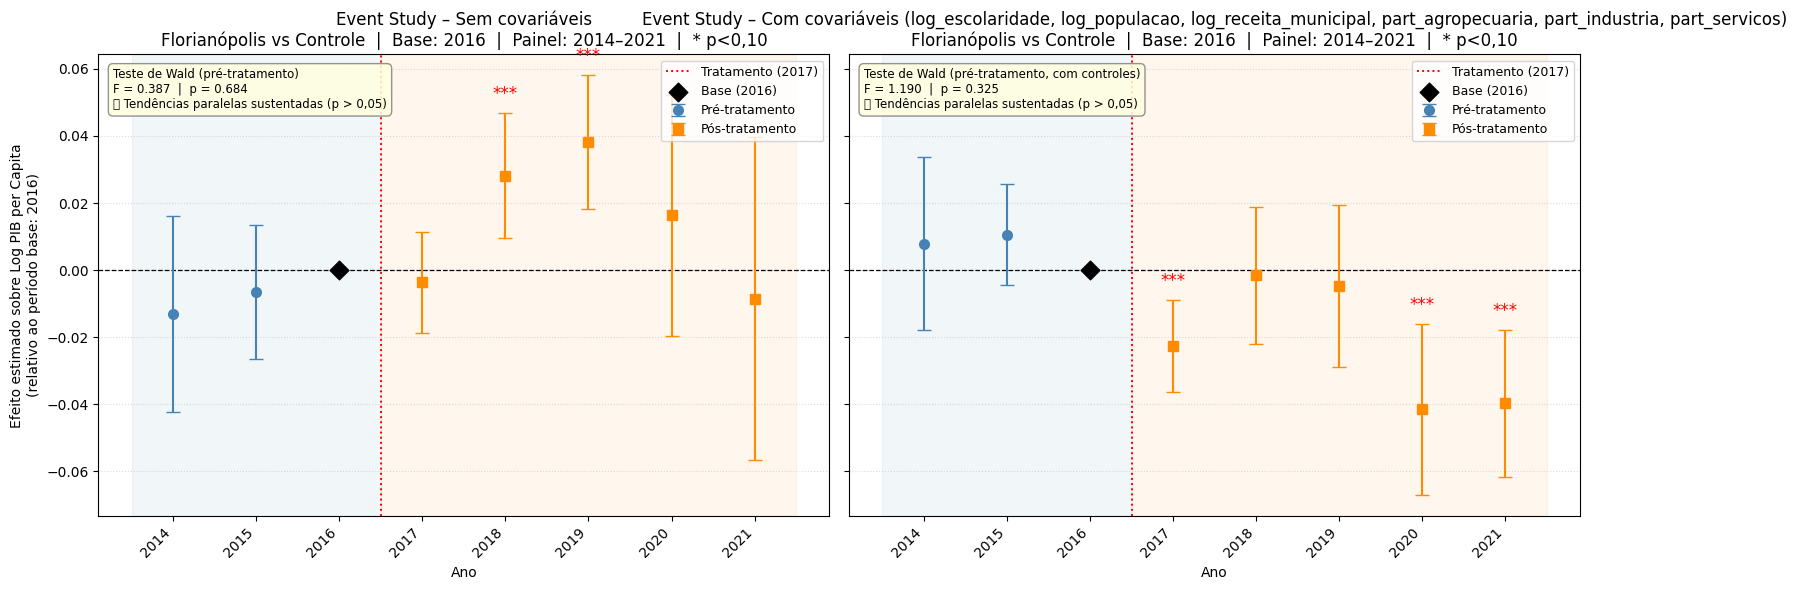

In [99]:
# ================================================================
# 4. Gráfico comparativo: Event Study sem vs. com covariáveis
# ================================================================
# O painel da esquerda usa df_coef (todos os anos disponíveis, sem controles).
# O painel da direita usa df_coef_ctrl (painel até ano_final_es, com controles).

# Restringe df_coef ao mesmo horizonte temporal para comparação justa
df_coef_base = df_coef[df_coef["t_rel"].apply(
    lambda t: (ano_tratamento + t) <= ano_final_es
)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

anos_eixo_ctrl = sorted(df_coef_ctrl["t_rel"].unique())

configs = [
    (axes[0], df_coef_base,  msg_wald,      "Sem covariáveis"),
    (axes[1], df_coef_ctrl,  msg_wald_ctrl,
     f"Com covariáveis ({', '.join(covariaveis_es_validas)})"),
]

for ax, df_c_full, msg, titulo in configs:
    df_c_pre = df_c_full[df_c_full["t_rel"] <  0]
    df_c_pos = df_c_full[df_c_full["t_rel"] >= 0]

    ax.axvspan(min(anos_eixo_ctrl) - 0.5, -0.5, alpha=0.07, color="steelblue")
    ax.axvspan(-0.5, max(anos_eixo_ctrl) + 0.5, alpha=0.07, color="darkorange")
    ax.axhline(0, color="black", linewidth=0.9, linestyle="--")
    ax.axvline(-0.5, color="red", linewidth=1.4, linestyle=":",
               label=f"Tratamento ({ano_tratamento})")

    for dados, fmt, cor, label in [
        (df_c_pre, "o", "steelblue",  "Pré-tratamento"),
        (df_c_pos, "s", "darkorange", "Pós-tratamento"),
    ]:
        ax.errorbar(
            dados["t_rel"], dados["coef"],
            yerr=[dados["coef"] - dados["ci_low"],
                  dados["ci_high"] - dados["coef"]],
            fmt=fmt, color=cor, ecolor=cor,
            elinewidth=1.5, capsize=5, markersize=7, label=label,
        )

    ax.scatter(-1, 0, color="black", zorder=5, s=90,
               marker="D", label=f"Base ({ano_pre_tratamento})")

    for _, row in df_c_full.iterrows():
        if not np.isnan(row["pval"]) and row["pval"] < 0.1:
            stars = "***" if row["pval"] < 0.01 else "**" if row["pval"] < 0.05 else "*"
            ax.text(row["t_rel"], row["ci_high"] + 0.003, stars,
                    ha="center", va="bottom", fontsize=12, color="red")

    ax.text(
        0.02, 0.97, msg,
        transform=ax.transAxes, fontsize=8.5,
        verticalalignment="top", horizontalalignment="left",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow",
                  edgecolor="gray", alpha=0.85),
    )

    ax.set_xticks(anos_eixo_ctrl)
    ax.set_xticklabels(
        [str(ano_tratamento + t) for t in anos_eixo_ctrl],
        rotation=45, ha="right"
    )
    ax.set_xlabel("Ano")
    ax.set_title(
        f"Event Study – {titulo}\n"
        f"Florianópolis vs Controle  |  Base: {ano_pre_tratamento}  "
        f"|  Painel: {anos_es[0]}–{anos_es[-1]}  |  * p<0,10"
    )
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(axis="y", linestyle=":", alpha=0.45)

axes[0].set_ylabel(
    f"Efeito estimado sobre Log PIB per Capita\n"
    f"(relativo ao período base: {ano_pre_tratamento})"
)
plt.tight_layout()
plt.show()


In [100]:
# ================================================================
# 5. Tabela de efeitos pós-tratamento — modelo com covariáveis
# ================================================================

def sig(p):
    if np.isnan(p): return ""
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""

resumo_ctrl = (
    df_coef_ctrl[df_coef_ctrl["t_rel"] >= 0]
    .assign(
        ano        = lambda d: ano_tratamento + d["t_rel"],
        sig        = lambda d: d["pval"].apply(sig),
        efeito_pct = lambda d: (np.exp(d["coef"]) - 1) * 100,
    )
    .rename(columns={
        "t_rel"     : "t",
        "coef"      : "Coef.",
        "ci_low"    : "IC 2,5%",
        "ci_high"   : "IC 97,5%",
        "pval"      : "p-valor",
        "sig"       : "Sig.",
        "efeito_pct": "Efeito (%)",
    })
    [["ano", "t", "Coef.", "IC 2,5%", "IC 97,5%", "Efeito (%)", "p-valor", "Sig."]]
)

print(f"=== Efeitos pós-tratamento — com covariáveis ===")
print(f"Painel   : {anos_es[0]} – {anos_es[-1]}")
print(f"Covariáveis: {covariaveis_es_validas}")
print(resumo_ctrl.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nNota: Erros clusterizados por município. * p<0,10  ** p<0,05  *** p<0,01")


=== Efeitos pós-tratamento — com covariáveis ===
Painel   : 2014 – 2021
Covariáveis: ['log_escolaridade', 'log_populacao', 'log_receita_municipal', 'part_agropecuaria', 'part_industria', 'part_servicos']
 ano  t   Coef.  IC 2,5%  IC 97,5%  Efeito (%)  p-valor Sig.
2017  0 -0.0225  -0.0363   -0.0088     -2.2297   0.0013  ***
2018  1 -0.0016  -0.0220    0.0188     -0.1596   0.8779     
2019  2 -0.0048  -0.0290    0.0195     -0.4740   0.7006     
2020  3 -0.0415  -0.0670   -0.0160     -4.0660   0.0014  ***
2021  4 -0.0398  -0.0616   -0.0179     -3.8974   0.0004  ***

Nota: Erros clusterizados por município. * p<0,10  ** p<0,05  *** p<0,01


In [101]:
# ================================================================
# 6. Coeficientes das covariáveis no modelo com controles
# ================================================================

ci_ctrl_full = modelo_es_ctrl.conf_int()

linhas_cov_es = []
for var in covariaveis_es_validas:
    if var not in modelo_es_ctrl.params.index:
        continue
    linhas_cov_es.append({
        "Covariável": var,
        "Coef."     : float(modelo_es_ctrl.params[var]),
        "Erro Pad." : float(modelo_es_ctrl.bse[var]),
        "p-valor"   : float(modelo_es_ctrl.pvalues[var]),
        "IC 2,5%"   : float(ci_ctrl_full.loc[var, 0]),
        "IC 97,5%"  : float(ci_ctrl_full.loc[var, 1]),
        "Sig."      : sig(float(modelo_es_ctrl.pvalues[var])),
    })

df_cov_es = pd.DataFrame(linhas_cov_es)
print("=== Covariáveis no Event Study com Controles ===")
print(df_cov_es.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nN = {int(modelo_es_ctrl.nobs):,}  |  R² = {modelo_es_ctrl.rsquared:.4f}  "
      f"|  EF município: sim  |  EF ano: sim")


=== Covariáveis no Event Study com Controles ===
           Covariável  Coef.  Erro Pad.  p-valor  IC 2,5%  IC 97,5% Sig.
     log_escolaridade 0.0345     0.2568   0.8931  -0.4689    0.5379     
        log_populacao 0.9052     0.3059   0.0031   0.3057    1.5047  ***
log_receita_municipal 0.1417     0.1034   0.1706  -0.0610    0.3445     
    part_agropecuaria 0.0416     0.0213   0.0509  -0.0002    0.0834    *
       part_industria 0.0342     0.0058   0.0000   0.0228    0.0455  ***
        part_servicos 0.0293     0.0065   0.0000   0.0165    0.0421  ***

N = 168  |  R² = 0.9989  |  EF município: sim  |  EF ano: sim


## Dif in Dif para o PIB - 2016 Vs 2023


In [102]:
# ================================================================
# FUNÇÃO PADRÃO: DiD
# ================================================================

def estimar_did_2x2(
    df_base,
    ids_controle,
    municipio_tratado,
    ano_pre,
    ano_pos,
    var_dep,
    excluir_covariaveis,
):

    ids = ids_controle + [municipio_tratado]

    df = (
        df_base[
            (df_base["id_municipio"].isin(ids)) &
            (df_base["ano"].isin([ano_pre, ano_pos]))
        ]
        .copy()
        .assign(
            tratado=lambda d: (d["id_municipio"] == municipio_tratado).astype(int),
            pos=lambda d: (d["ano"] == ano_pos).astype(int),
        )
    )

    df["interacao"] = df["tratado"] * df["pos"]

    # -----------------------------------------------------------
    # Seleção automática de covariáveis
    # -----------------------------------------------------------

    numericas = df_base.select_dtypes(include="number").columns.tolist()

    excluir_total = [
        "tratamento",
        "ano",
        "id_municipio",
        "tratado",
        "pos",
        "interacao",
        var_dep,
    ] + excluir_covariaveis

    candidatas = [c for c in numericas if c not in excluir_total]

    covariaveis = [c for c in candidatas if df[c].notna().any()]

    # -----------------------------------------------------------
    # Matriz de regressão
    # -----------------------------------------------------------

    y = df[var_dep].astype(float)

    # dentro da função, antes do OLS
    X = df[["tratado", "pos", "interacao"] + covariaveis].astype(float)
    X = sm.add_constant(X)

    # remover colunas constantes ou colineares
    X = X.loc[:, X.nunique() > 1]

    # remover missing
    X = X.dropna()
    y = y.loc[X.index]

    modelo = sm.OLS(y, X).fit(cov_type="HC1")

    return modelo, df, covariaveis

O resultado aponta para o efeito do tratamento sobre o log PIB per capita (2016 vs 2023), significativo a 10% de significância


=== DiD – log PIB per capita (2016 vs 2023) ===
Variáveis excluídas por missing: ['log_pib_servicos', 'part_agropecuaria', 'part_industria', 'part_servicos']
Covariáveis usadas:              ['log_escolaridade', 'log_populacao', 'log_receita_municipal']
Coef. DiD:                       -0.14156425
Erro padrão HC1:                 0.06146983
p-valor:                         0.021280
IC 95%:                          [-0.26204291, -0.02108558]
Efeito percentual:               -13.200%
IC 95% (%):                      [-23.052%, -2.086%]
Observações:                     42

--- Coeficientes das Covariáveis ---
           Covariável       Coef.  Erro Pad.    p-valor     IC 2.5%    IC 97.5%
     log_escolaridade -3.00347302 0.89870323 0.00083175 -4.76489897 -1.24204706
        log_populacao -0.18214553 0.14440221 0.20717330 -0.46516867  0.10087761
log_receita_municipal  1.17773689 0.16448592 0.00000000  0.85535042  1.50012337


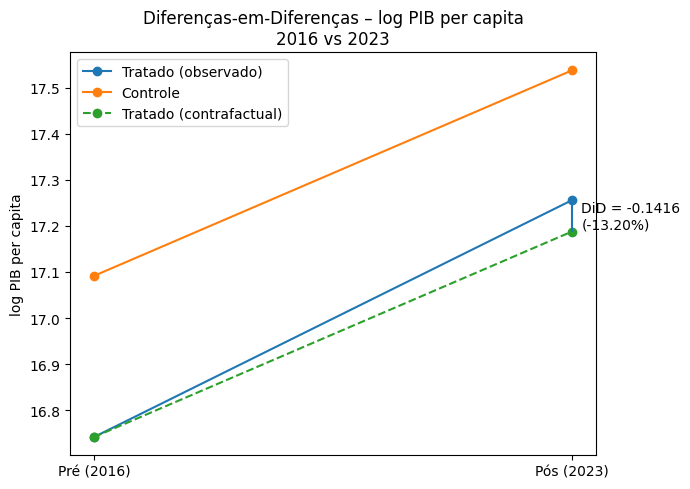

In [103]:
# ================================================================
# SEÇÃO 2: DiD – log PIB per capita (2016 vs 2023)
# ================================================================

var_dep_pib       = "log_pib_per_capita"
ano_pos_pib       = 2023
ids_controle_full = grupo_controle["id_municipio"].tolist()
todos_ids_pib     = ids_controle_full + [municipio_tratado]

excluir_fixo_pib = [
    "tratamento", "ano", "id_municipio",
    var_dep_pib,
    "%_pib_per_capita",
    "%_pib_servicos",
    "part_adm_publica",
]

missing_pib       = detectar_variaveis_com_missing(
    df_matching, todos_ids_pib,
    anos=[ano_pre_tratamento, ano_pos_pib],
    excluir_fixo=excluir_fixo_pib,
)
excluir_total_pib = list(set(excluir_fixo_pib + missing_pib))

modelo_pib, df_pib, covs_pib = estimar_did_2x2(
    df_matching,
    ids_controle_full,
    municipio_tratado,
    ano_pre_tratamento,
    ano_pos_pib,
    var_dep_pib,
    excluir_covariaveis=excluir_total_pib,
)

# ================================================================
# SEÇÃO 3: Resultados e gráfico – log PIB per capita (2016 vs 2023)
# ================================================================

def limpar_zero(x):
    return 0.0 if pd.notna(x) and np.isclose(x, 0, atol=1e-12) else x

coef_pib    = limpar_zero(float(modelo_pib.params.get("interacao", np.nan)))
se_pib      = limpar_zero(float(modelo_pib.bse.get("interacao", np.nan)))
p_pib       = float(modelo_pib.pvalues.get("interacao", np.nan))
ci_pib      = modelo_pib.conf_int().loc["interacao"]
ci_low_pib  = limpar_zero(ci_pib[0])
ci_high_pib = limpar_zero(ci_pib[1])

did_pct_pib     = np.exp(coef_pib) - 1
ci_pct_low_pib  = np.exp(ci_low_pib) - 1
ci_pct_high_pib = np.exp(ci_high_pib) - 1

pd.options.display.float_format = "{:.8f}".format

print(f"=== DiD – log PIB per capita ({ano_pre_tratamento} vs 2023) ===")
print(f"Variáveis excluídas por missing: {missing_pib}")
print(f"Covariáveis usadas:              {covs_pib}")
print(f"Coef. DiD:                       {coef_pib:.8f}")
print(f"Erro padrão HC1:                 {se_pib:.8f}")
print(f"p-valor:                         {p_pib:.6f}")
print(f"IC 95%:                          [{ci_low_pib:.8f}, {ci_high_pib:.8f}]")
print(f"Efeito percentual:               {did_pct_pib*100:.3f}%")
print(f"IC 95% (%):                      [{ci_pct_low_pib*100:.3f}%, {ci_pct_high_pib*100:.3f}%]")
print(f"Observações:                     {int(modelo_pib.nobs)}")

# --- Tabela de coeficientes das covariáveis ---
variaveis_principais = ["const", "tratado", "pos", "interacao"]

ci_all = modelo_pib.conf_int()

linhas_cov = []
for var in covs_pib:
    if var not in modelo_pib.params.index:
        continue
    linhas_cov.append({
        "Covariável" : var,
        "Coef."      : limpar_zero(float(modelo_pib.params[var])),
        "Erro Pad."  : limpar_zero(float(modelo_pib.bse[var])),
        "p-valor"    : float(modelo_pib.pvalues[var]),
        "IC 2.5%"    : limpar_zero(float(ci_all.loc[var, 0])),
        "IC 97.5%"   : limpar_zero(float(ci_all.loc[var, 1])),
    })

df_cov_pib = pd.DataFrame(linhas_cov)

print("\n--- Coeficientes das Covariáveis ---")
print(df_cov_pib.to_string(index=False))

# --- Gráfico ---
medias_pib        = df_pib.groupby(["tratado", "pos"])[var_dep_pib].mean().unstack()
y_trat_pre_pib    = float(medias_pib.loc[1, 0])
y_trat_pos_pib    = float(medias_pib.loc[1, 1])
y_ctrl_pre_pib    = float(medias_pib.loc[0, 0])
y_ctrl_pos_pib    = float(medias_pib.loc[0, 1])
contrafactual_pib = y_trat_pre_pib + (y_ctrl_pos_pib - y_ctrl_pre_pib)

fig, ax = plt.subplots(figsize=(7, 5))
x = [0, 1]
ax.plot(x, [y_trat_pre_pib, y_trat_pos_pib], marker="o", label="Tratado (observado)")
ax.plot(x, [y_ctrl_pre_pib, y_ctrl_pos_pib], marker="o", label="Controle")
ax.plot(x, [y_trat_pre_pib, contrafactual_pib],
        linestyle="--", marker="o", label="Tratado (contrafactual)")
ax.vlines(1, contrafactual_pib, y_trat_pos_pib)
ax.text(1.02, (y_trat_pos_pib + contrafactual_pib) / 2,
        f"DiD = {coef_pib:.4f}\n({did_pct_pib*100:.2f}%)", va="center")
ax.set_xticks([0, 1])
ax.set_xticklabels([f"Pré ({ano_pre_tratamento})", "Pós (2023)"])
ax.set_ylabel("log PIB per capita")
ax.set_title(f"Diferenças-em-Diferenças – log PIB per capita\n{ano_pre_tratamento} vs 2023")
ax.legend()
plt.tight_layout()
plt.show()

In [104]:
# ================================================================
# SEÇÃO 6: Função Leave-One-Out genérica
# ================================================================

def leave_one_out(
    df_matching,
    ids_controle_full,
    municipio_tratado,
    ano_pre_tratamento,
    ano_pos,
    var_dep,
    excluir_fixo,
    mapa_id_nome,
):
    """
    Roda o DiD removendo um município do grupo de controle por vez.
    A detecção de missing é feita silenciosamente em cada iteração.

    Retorna
    -------
    DataFrame com coeficientes, IC e p-valor por iteração
    """
    resultados = []

    for id_removido in ids_controle_full:

        ids_sem   = [i for i in ids_controle_full if i != id_removido]
        nome      = mapa_id_nome.get(id_removido, str(id_removido))
        todos_ids = ids_sem + [municipio_tratado]

        try:
            missing = detectar_variaveis_com_missing(
                df_matching,
                todos_ids,
                anos=[ano_pre_tratamento, ano_pos],
                excluir_fixo=excluir_fixo,
            )
            excluir_iter = list(set(excluir_fixo + missing))

            modelo, _, covs = estimar_did_2x2(
                df_matching,
                ids_sem,
                municipio_tratado,
                ano_pre_tratamento,
                ano_pos,
                var_dep,
                excluir_covariaveis=excluir_iter,
            )

            coef              = limpar_zero(float(modelo.params.get("interacao", np.nan)))
            se                = limpar_zero(float(modelo.bse.get("interacao", np.nan)))
            pval              = float(modelo.pvalues.get("interacao", np.nan))
            ci_low_l, ci_high_l = modelo.conf_int().loc["interacao"]
            ci_low_l          = limpar_zero(ci_low_l)
            ci_high_l         = limpar_zero(ci_high_l)
            nobs              = int(modelo.nobs)

        except Exception:
            coef = se = pval = nobs = np.nan
            ci_low_l = ci_high_l = np.nan
            covs = []

        resultados.append({
            "Município removido" : nome,
            "Coef. DiD"         : coef,
            "Erro padrão"       : se,
            "IC 2.5%"           : ci_low_l,
            "IC 97.5%"          : ci_high_l,
            "p-valor"           : pval,
            "N"                 : nobs,
            "N covariáveis"     : len(covs),
        })

    return pd.DataFrame(resultados)

Análise de sensiblidade retirando municípios de forma individual do grupo de controle.

=== Leave-One-Out – log PIB per capita (2016 vs 2023) ===
   Município removido   Coef. DiD  Erro padrão     IC 2.5%    IC 97.5%    p-valor  N  N covariáveis
             Salvador -0.15637705   0.06315739 -0.28016325 -0.03259085 0.01328673 40              3
            Fortaleza -0.15439706   0.06215713 -0.27622280 -0.03257131 0.01299232 40              3
      Itaquaquecetuba -0.15050071   0.06643953 -0.28071981 -0.02028161 0.02349868 40              3
                 Mauá -0.14988416   0.06072543 -0.26890381 -0.03086451 0.01357840 40              3
               Cuiabá -0.14730264   0.06344198 -0.27164663 -0.02295865 0.02024111 40              3
               Recife -0.14715150   0.06418394 -0.27294971 -0.02135328 0.02186800 40              3
               Maceió -0.14458715   0.06146867 -0.26506352 -0.02411078 0.01866228 40              3
             São Luís -0.14444657   0.06403988 -0.26996242 -0.01893071 0.02409744 40              3
             Londrina -0.14327296   0.0644

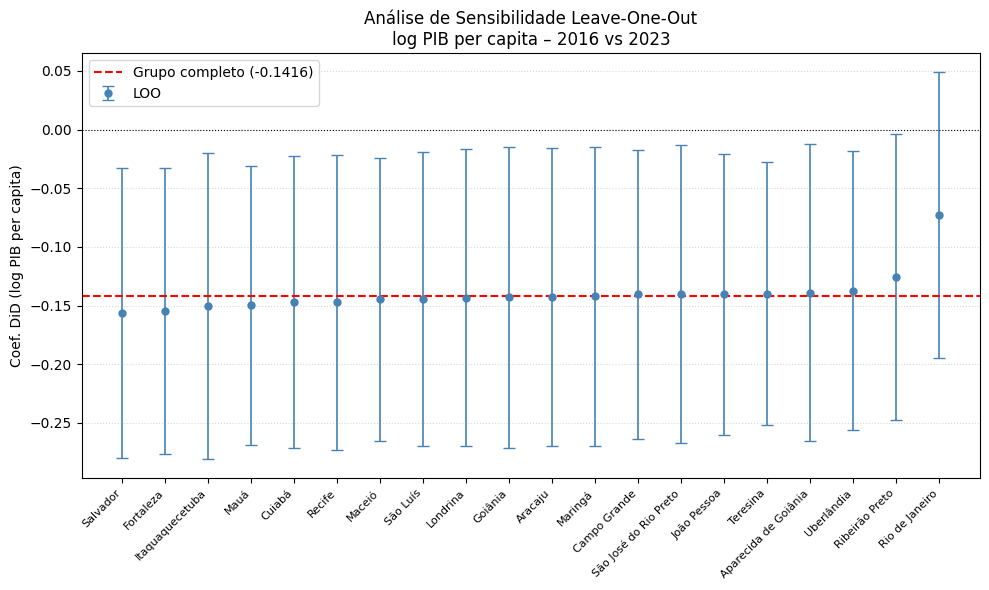

In [105]:
# ================================================================
# SEÇÃO 7: Leave-One-Out – log PIB per capita (2016 vs 2023)
# ================================================================

mapa_id_nome = (
    df_matching[["id_municipio", "municipio"]]
    .drop_duplicates()
    .set_index("id_municipio")["municipio"]
    .to_dict()
)

df_loo_pib = leave_one_out(
    df_matching,
    ids_controle_full,
    municipio_tratado,
    ano_pre_tratamento,
    ano_pos_pib,
    var_dep_pib,
    excluir_fixo_pib,
    mapa_id_nome,
)

linha_full_pib = pd.DataFrame([{
    "Município removido" : "— GRUPO COMPLETO —",
    "Coef. DiD"         : coef_pib,
    "Erro padrão"       : se_pib,
    "IC 2.5%"           : ci_low_pib,
    "IC 97.5%"          : ci_high_pib,
    "p-valor"           : p_pib,
    "N"                 : int(modelo_pib.nobs),
    "N covariáveis"     : len(covs_pib),
}])

df_loo_pib = (
    pd.concat([linha_full_pib, df_loo_pib], ignore_index=True)
    .sort_values("Coef. DiD")
    .reset_index(drop=True)
)

print(f"=== Leave-One-Out – log PIB per capita ({ano_pre_tratamento} vs 2023) ===")
print(df_loo_pib.to_string(index=False))

# ================================================================
# SEÇÃO 8: Gráfico Leave-One-Out – log PIB per capita (2016 vs 2023)
# ================================================================

df_loo_pib_plot = df_loo_pib[
    df_loo_pib["Município removido"] != "— GRUPO COMPLETO —"
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    range(len(df_loo_pib_plot)),
    df_loo_pib_plot["Coef. DiD"],
    yerr=[
        df_loo_pib_plot["Coef. DiD"] - df_loo_pib_plot["IC 2.5%"],
        df_loo_pib_plot["IC 97.5%"]  - df_loo_pib_plot["Coef. DiD"],
    ],
    fmt="o", color="steelblue", ecolor="steelblue",
    elinewidth=1.2, capsize=4, markersize=5, label="LOO",
)

ax.axhline(coef_pib, color="red", linestyle="--", linewidth=1.5,
           label=f"Grupo completo ({coef_pib:.4f})")
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")

ax.set_xticks(range(len(df_loo_pib_plot)))
ax.set_xticklabels(df_loo_pib_plot["Município removido"],
                   rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Coef. DiD (log PIB per capita)")
ax.set_title(f"Análise de Sensibilidade Leave-One-Out\nlog PIB per capita – {ano_pre_tratamento} vs 2023")
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

## Dif in Dif para o crescimento do PIB - 2016 Vs 2023


De forma complementar, foi estimado o impacto sobre o crescimento do pib per capita. Obteve-se o coeficiente 0.10 (10 pontos percentuais),significativo com 99% de confiança

In [106]:
# ================================================================
# CONFIGURAÇÃO – DiD % Crescimento PIB per capita
# ================================================================


var_dep_pib       = "%_pib_per_capita"
ano_pos_pib       = 2023
ids_controle_full = grupo_controle["id_municipio"].tolist()
todos_ids_pib     = ids_controle_full + [municipio_tratado]

excluir_fixo_pib = [
    "tratamento", "ano", "id_municipio",
    var_dep_pib,
    "log_pib_per_capita",
    "%_pib_servicos",
    "part_adm_publica",
]

missing_pib        = detectar_variaveis_com_missing(
    df_matching, todos_ids_pib,
    anos=[ano_pre_tratamento, ano_pos_pib],
    excluir_fixo=excluir_fixo_pib,
)
excluir_total_pib  = list(set(excluir_fixo_pib + missing_pib))

modelo_pib, df_pib, covs_pib = estimar_did_2x2(
    df_matching,
    ids_controle_full,
    municipio_tratado,
    ano_pre_tratamento,
    ano_pos_pib,
    var_dep_pib,
    excluir_covariaveis=excluir_total_pib,
)

# ── Teste de tendências paralelas – % Crescimento PIB per capita ──
# H0: coef(ano_c × tratado) = 0  →  tendências paralelas
# Usa sm.OLS diretamente para evitar problemas de parsing do patsy
# com nomes de variáveis que contêm caracteres especiais (%, espaço etc.)
_df_pre_pct = (
    df_matching[
        (df_matching["id_municipio"].isin(ids_controle_full + [municipio_tratado]))
        & (df_matching["ano"] < ano_pre_tratamento)
        & df_matching["%_pib_per_capita"].notna()
    ]
    .copy()
    .assign(
        tratado = lambda d: (d["id_municipio"] == municipio_tratado).astype(int),
        ano_c   = lambda d: (d["ano"] - d["ano"].min()).astype(float),
    )
)
_df_pre_pct["interacao_tend"] = (
    _df_pre_pct["ano_c"] * _df_pre_pct["tratado"]
)

_X_tend_pct = sm.add_constant(
    _df_pre_pct[["ano_c", "tratado", "interacao_tend"]].astype(float)
)
_y_tend_pct = _df_pre_pct["%_pib_per_capita"].astype(float)

_mod_tend_pct = sm.OLS(_y_tend_pct, _X_tend_pct).fit(cov_type="HC1")

_coef_tend_pct = _mod_tend_pct.params.get("interacao_tend", np.nan)
_pval_tend_pct = _mod_tend_pct.pvalues.get("interacao_tend", np.nan)
_sinal_tend_pct = (
    "✅ Não rejeitamos H0: tendências paralelas sustentadas."
    if _pval_tend_pct > 0.05
    else "⚠️  Rejeitamos H0: evidência contra tendências paralelas."
)

print("=== Teste de Tendências Paralelas – % Crescimento PIB per capita ===")
print(f"Coef. interação (ano × tratado): {_coef_tend_pct:.6f}  "
      f"|  p-valor: {_pval_tend_pct:.4f}")
print(_sinal_tend_pct)
print()


=== Teste de Tendências Paralelas – % Crescimento PIB per capita ===
Coef. interação (ano × tratado): -0.009032  |  p-valor: 0.5926
✅ Não rejeitamos H0: tendências paralelas sustentadas.



=== DiD – % Crescimento do PIB per Capita (2016 vs 2023) ===
Variáveis excluídas por missing: ['log_pib_servicos', 'part_agropecuaria', 'part_industria', 'part_servicos']
Covariáveis usadas:              ['log_escolaridade', 'log_populacao', 'log_receita_municipal']
Coef. DiD:                       0.07562521
Erro padrão HC1:                 0.01649112
p-valor:                         0.000005
Observações:                     42

--- Coeficientes das Covariáveis ---
           Covariável       Coef.  Erro Pad.    p-valor     IC 2.5%   IC 97.5%
     log_escolaridade  0.08303476 0.14802294 0.57482569 -0.20708488 0.37315439
        log_populacao  0.00244560 0.02775684 0.92979089 -0.05195681 0.05684801
log_receita_municipal -0.00655350 0.02921995 0.82253822 -0.06382355 0.05071656


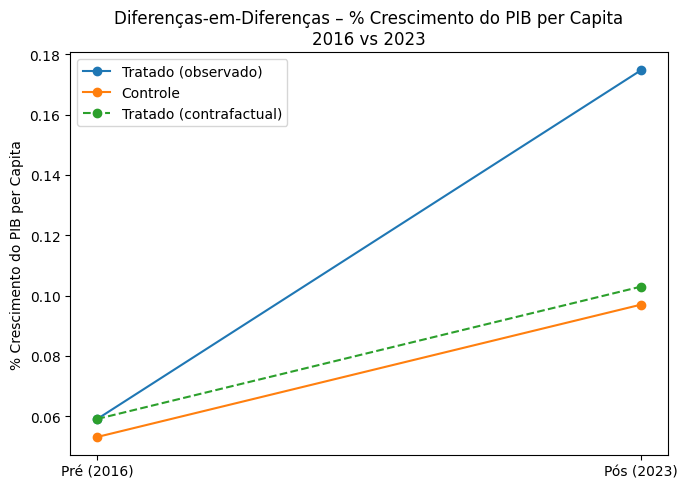

In [107]:
def limpar_zero(x):
    return 0.0 if pd.notna(x) and np.isclose(x, 0, atol=1e-12) else x

coef_pib    = limpar_zero(float(modelo_pib.params.get("interacao", np.nan)))
se_pib      = limpar_zero(float(modelo_pib.bse.get("interacao", np.nan)))
p_pib       = float(modelo_pib.pvalues.get("interacao", np.nan))
ci_pib      = modelo_pib.conf_int().loc["interacao"]
ci_low_pib  = limpar_zero(ci_pib[0])
ci_high_pib = limpar_zero(ci_pib[1])

pd.options.display.float_format = "{:.8f}".format

print(f"=== DiD – % Crescimento do PIB per Capita ({ano_pre_tratamento} vs 2023) ===")
print(f"Variáveis excluídas por missing: {missing_pib}")
print(f"Covariáveis usadas:              {covs_pib}")
print(f"Coef. DiD:                       {coef_pib:.8f}")
print(f"Erro padrão HC1:                 {se_pib:.8f}")
print(f"p-valor:                         {p_pib:.6f}")
print(f"Observações:                     {int(modelo_pib.nobs)}")

# --- Tabela de coeficientes das covariáveis ---
ci_all = modelo_pib.conf_int()

linhas_cov = []
for var in covs_pib:
    if var not in modelo_pib.params.index:
        continue
    linhas_cov.append({
        "Covariável" : var,
        "Coef."      : limpar_zero(float(modelo_pib.params[var])),
        "Erro Pad."  : limpar_zero(float(modelo_pib.bse[var])),
        "p-valor"    : float(modelo_pib.pvalues[var]),
        "IC 2.5%"    : limpar_zero(float(ci_all.loc[var, 0])),
        "IC 97.5%"   : limpar_zero(float(ci_all.loc[var, 1])),
    })

df_cov_pib = pd.DataFrame(linhas_cov)

print("\n--- Coeficientes das Covariáveis ---")
print(df_cov_pib.to_string(index=False))

# --- Gráfico ---
medias_pib        = df_pib.groupby(["tratado", "pos"])[var_dep_pib].mean().unstack()
y_trat_pre_pib    = float(medias_pib.loc[1, 0])
y_trat_pos_pib    = float(medias_pib.loc[1, 1])
y_ctrl_pre_pib    = float(medias_pib.loc[0, 0])
y_ctrl_pos_pib    = float(medias_pib.loc[0, 1])
contrafactual_pib = y_trat_pre_pib + (y_ctrl_pos_pib - y_ctrl_pre_pib)

fig, ax = plt.subplots(figsize=(7, 5))
x = [0, 1]
ax.plot(x, [y_trat_pre_pib, y_trat_pos_pib], marker="o", label="Tratado (observado)")
ax.plot(x, [y_ctrl_pre_pib, y_ctrl_pos_pib], marker="o", label="Controle")
ax.plot(x, [y_trat_pre_pib, contrafactual_pib],
        linestyle="--", marker="o", label="Tratado (contrafactual)")
ax.set_xticks([0, 1])
ax.set_xticklabels([f"Pré ({ano_pre_tratamento})", "Pós (2023)"])
ax.set_ylabel("% Crescimento do PIB per Capita")
ax.set_title(f"Diferenças-em-Diferenças – % Crescimento do PIB per Capita\n{ano_pre_tratamento} vs 2023")
ax.legend()
plt.tight_layout()
plt.show()

=== Leave-One-Out – % Crescimento PIB per capita (2016 vs 2023) ===
   Município removido  Coef. DiD  Erro padrão    IC 2.5%   IC 97.5%    p-valor  N  N covariáveis
                 Mauá 0.06322091   0.01095381 0.04175185 0.08468998 0.00000001 40              3
           Uberlândia 0.07160672   0.01698512 0.03831650 0.10489694 0.00002488 40              3
              Maringá 0.07177976   0.01653799 0.03936590 0.10419361 0.00001423 40              3
         Campo Grande 0.07250275   0.01681966 0.03953683 0.10546867 0.00001628 40              3
            Fortaleza 0.07376760   0.01733186 0.03979778 0.10773741 0.00002079 40              3
             São Luís 0.07419620   0.01724257 0.04040138 0.10799102 0.00001684 40              3
             Londrina 0.07478029   0.01715314 0.04116076 0.10839983 0.00001303 40              3
       Ribeirão Preto 0.07522931   0.01713618 0.04164301 0.10881561 0.00001133 40              3
   — GRUPO COMPLETO — 0.07562521   0.01649112 0.04330321 0.

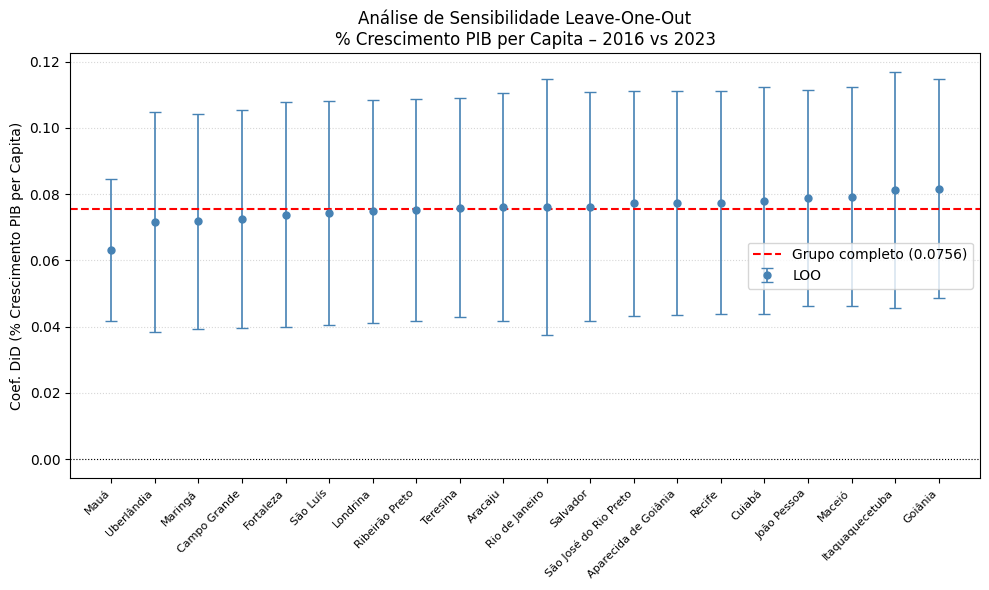

In [108]:

mapa_id_nome = (
    df_matching[["id_municipio", "municipio"]]
    .drop_duplicates()
    .set_index("id_municipio")["municipio"]
    .to_dict()
)

df_loo_pib = leave_one_out(
    df_matching,
    ids_controle_full,
    municipio_tratado,
    ano_pre_tratamento,
    ano_pos_pib,
    var_dep_pib,
    excluir_fixo_pib,
    mapa_id_nome,
)

linha_full_pib = pd.DataFrame([{
    "Município removido" : "— GRUPO COMPLETO —",
    "Coef. DiD"         : coef_pib,
    "Erro padrão"       : se_pib,
    "IC 2.5%"           : ci_low_pib,
    "IC 97.5%"          : ci_high_pib,
    "p-valor"           : p_pib,
    "N"                 : int(modelo_pib.nobs),
    "N covariáveis"     : len(covs_pib),
}])

df_loo_pib = (
    pd.concat([linha_full_pib, df_loo_pib], ignore_index=True)
    .sort_values("Coef. DiD")
    .reset_index(drop=True)
)

print(f"=== Leave-One-Out – % Crescimento PIB per capita ({ano_pre_tratamento} vs 2023) ===")
print(df_loo_pib.to_string(index=False))

# ================================================================
# SEÇÃO 8: Gráfico Leave-One-Out – log PIB per capita (2016 vs 2023)
# ================================================================

df_loo_pib_plot = df_loo_pib[
    df_loo_pib["Município removido"] != "— GRUPO COMPLETO —"
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    range(len(df_loo_pib_plot)),
    df_loo_pib_plot["Coef. DiD"],
    yerr=[
        df_loo_pib_plot["Coef. DiD"] - df_loo_pib_plot["IC 2.5%"],
        df_loo_pib_plot["IC 97.5%"]  - df_loo_pib_plot["Coef. DiD"],
    ],
    fmt="o", color="steelblue", ecolor="steelblue",
    elinewidth=1.2, capsize=4, markersize=5, label="LOO",
)

ax.axhline(coef_pib, color="red", linestyle="--", linewidth=1.5,
           label=f"Grupo completo ({coef_pib:.4f})")
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")

ax.set_xticks(range(len(df_loo_pib_plot)))
ax.set_xticklabels(df_loo_pib_plot["Município removido"],
                   rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Coef. DiD (% Crescimento PIB per Capita)")
ax.set_title(f"Análise de Sensibilidade Leave-One-Out\n% Crescimento PIB per Capita – {ano_pre_tratamento} vs 2023")
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

## Dif in Dif para o PIB de Serviços
Análise alternativa para o PIB de Serviços, considerando somente até 2019 devido os dados setoriais serem restritos até 2021 e evitarmos contaminar com a pandemia.  
O resultado mostra um coeficiente negativo, embora não significativo

=== Teste de Tendências Paralelas – log PIB de Serviços ===
Coef. interação (ano × tratado): -0.010948  |  p-valor: 0.9692
✅ Não rejeitamos H0: tendências paralelas sustentadas.

=== DiD – log PIB de Serviços (2016 vs 2019) ===
Variáveis excluídas por missing: []
Covariáveis usadas:              ['log_escolaridade', 'part_servicos', 'part_industria', 'part_agropecuaria', 'log_populacao', 'log_receita_municipal']
Coef.:                           -0.05382057
Erro padrão HC1:                 0.04376659
p-valor:                         0.218803
IC 95%:                          [-0.13960150, 0.03196037]
Efeito percentual:               -5.240%
IC 95% (%):                      [-13.030%, 3.248%]
Observações:                     42

--- Coeficientes das Covariáveis ---
           Covariável       Coef.  Erro Pad.    p-valor     IC 2.5%    IC 97.5%
     log_escolaridade -2.83394583 0.71642454 0.00007632 -4.23811213 -1.42977953
        part_servicos  0.03928818 0.00551574 0.00000000  0.02847753

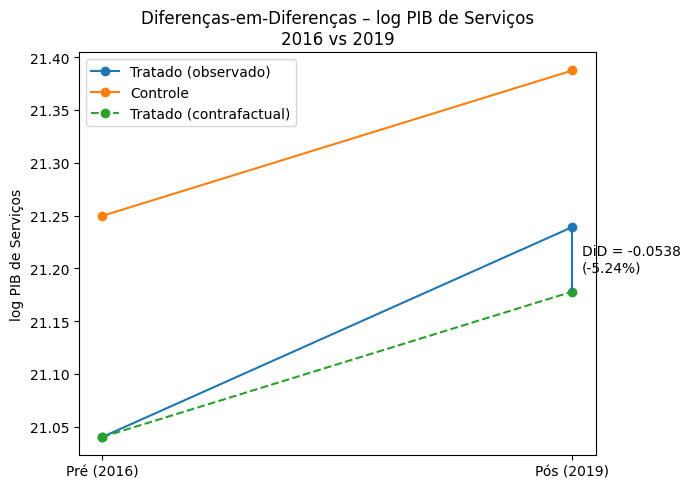

In [109]:
# ================================================================
# SEÇÃO 4: DiD – log PIB de Serviços (2016 vs 2019)
# ================================================================

var_dep_serv   = "log_pib_servicos"
ano_pos_serv   = 2019
todos_ids_serv = ids_controle_full + [municipio_tratado]

excluir_fixo_serv = [
    "tratamento", "ano", "id_municipio",
    var_dep_serv,
    "log_pib_per_capita",
    "%_pib_per_capita",
    "%_pib_servicos",
    "part_adm_publica",
]

missing_serv       = detectar_variaveis_com_missing(
    df_matching, todos_ids_serv,
    anos=[ano_pre_tratamento, ano_pos_serv],
    excluir_fixo=excluir_fixo_serv,
)
excluir_total_serv = list(set(excluir_fixo_serv + missing_serv))

modelo_serv, df_serv, covs_serv = estimar_did_2x2(
    df_matching,
    ids_controle_full,
    municipio_tratado,
    ano_pre_tratamento,
    ano_pos_serv,
    var_dep_serv,
    excluir_covariaveis=excluir_total_serv,
)

# ================================================================

# ── Teste de tendências paralelas – log PIB de Serviços ──
# H0: coef(ano_c × tratado) = 0  →  tendências paralelas
# Usa sm.OLS diretamente para evitar problemas de parsing do patsy
# com nomes de variáveis que contêm caracteres especiais (%, espaço etc.)
_df_pre_serv = (
    df_matching[
        (df_matching["id_municipio"].isin(ids_controle_full + [municipio_tratado]))
        & (df_matching["ano"] < ano_pre_tratamento)
        & df_matching["log_pib_servicos"].notna()
    ]
    .copy()
    .assign(
        tratado = lambda d: (d["id_municipio"] == municipio_tratado).astype(int),
        ano_c   = lambda d: (d["ano"] - d["ano"].min()).astype(float),
    )
)
_df_pre_serv["interacao_tend"] = (
    _df_pre_serv["ano_c"] * _df_pre_serv["tratado"]
)

_X_tend_serv = sm.add_constant(
    _df_pre_serv[["ano_c", "tratado", "interacao_tend"]].astype(float)
)
_y_tend_serv = _df_pre_serv["log_pib_servicos"].astype(float)

_mod_tend_serv = sm.OLS(_y_tend_serv, _X_tend_serv).fit(cov_type="HC1")

_coef_tend_serv = _mod_tend_serv.params.get("interacao_tend", np.nan)
_pval_tend_serv = _mod_tend_serv.pvalues.get("interacao_tend", np.nan)
_sinal_tend_serv = (
    "✅ Não rejeitamos H0: tendências paralelas sustentadas."
    if _pval_tend_serv > 0.05
    else "⚠️  Rejeitamos H0: evidência contra tendências paralelas."
)

print("=== Teste de Tendências Paralelas – log PIB de Serviços ===")
print(f"Coef. interação (ano × tratado): {_coef_tend_serv:.6f}  "
      f"|  p-valor: {_pval_tend_serv:.4f}")
print(_sinal_tend_serv)
print()

# SEÇÃO 5: Resultados e gráfico – log PIB de Serviços (2016 vs 2019)
# ================================================================

coef_serv    = limpar_zero(float(modelo_serv.params.get("interacao", np.nan)))
se_serv      = limpar_zero(float(modelo_serv.bse.get("interacao", np.nan)))
p_serv       = float(modelo_serv.pvalues.get("interacao", np.nan))
ci_serv      = modelo_serv.conf_int().loc["interacao"]
ci_low_serv  = limpar_zero(ci_serv[0])
ci_high_serv = limpar_zero(ci_serv[1])

did_pct_serv     = np.exp(coef_serv) - 1
ci_pct_low_serv  = np.exp(ci_low_serv) - 1
ci_pct_high_serv = np.exp(ci_high_serv) - 1

print(f"=== DiD – log PIB de Serviços ({ano_pre_tratamento} vs 2019) ===")
print(f"Variáveis excluídas por missing: {missing_serv}")
print(f"Covariáveis usadas:              {covs_serv}")
print(f"Coef.:                           {coef_serv:.8f}")
print(f"Erro padrão HC1:                 {se_serv:.8f}")
print(f"p-valor:                         {p_serv:.6f}")
print(f"IC 95%:                          [{ci_low_serv:.8f}, {ci_high_serv:.8f}]")
print(f"Efeito percentual:               {did_pct_serv*100:.3f}%")
print(f"IC 95% (%):                      [{ci_pct_low_serv*100:.3f}%, {ci_pct_high_serv*100:.3f}%]")
print(f"Observações:                     {int(modelo_serv.nobs)}")

# --- Tabela de coeficientes das covariáveis ---
ci_all_serv = modelo_serv.conf_int()

linhas_cov_serv = []
for var in covs_serv:
    if var not in modelo_serv.params.index:
        continue
    linhas_cov_serv.append({
        "Covariável" : var,
        "Coef."      : limpar_zero(float(modelo_serv.params[var])),
        "Erro Pad."  : limpar_zero(float(modelo_serv.bse[var])),
        "p-valor"    : float(modelo_serv.pvalues[var]),
        "IC 2.5%"    : limpar_zero(float(ci_all_serv.loc[var, 0])),
        "IC 97.5%"   : limpar_zero(float(ci_all_serv.loc[var, 1])),
    })

df_cov_serv = pd.DataFrame(linhas_cov_serv)

print("\n--- Coeficientes das Covariáveis ---")
print(df_cov_serv.to_string(index=False))

# --- Gráfico ---
medias_serv        = df_serv.groupby(["tratado", "pos"])[var_dep_serv].mean().unstack()
y_trat_pre_serv    = float(medias_serv.loc[1, 0])
y_trat_pos_serv    = float(medias_serv.loc[1, 1])
y_ctrl_pre_serv    = float(medias_serv.loc[0, 0])
y_ctrl_pos_serv    = float(medias_serv.loc[0, 1])
contrafactual_serv = y_trat_pre_serv + (y_ctrl_pos_serv - y_ctrl_pre_serv)

fig, ax = plt.subplots(figsize=(7, 5))
x = [0, 1]
ax.plot(x, [y_trat_pre_serv, y_trat_pos_serv], marker="o", label="Tratado (observado)")
ax.plot(x, [y_ctrl_pre_serv, y_ctrl_pos_serv], marker="o", label="Controle")
ax.plot(x, [y_trat_pre_serv, contrafactual_serv],
        linestyle="--", marker="o", label="Tratado (contrafactual)")
ax.vlines(1, contrafactual_serv, y_trat_pos_serv)
ax.text(1.02, (y_trat_pos_serv + contrafactual_serv) / 2,
        f"DiD = {coef_serv:.4f}\n({did_pct_serv*100:.2f}%)", va="center")
ax.set_xticks([0, 1])
ax.set_xticklabels([f"Pré ({ano_pre_tratamento})", "Pós (2019)"])
ax.set_ylabel("log PIB de Serviços")
ax.set_title(f"Diferenças-em-Diferenças – log PIB de Serviços\n{ano_pre_tratamento} vs 2019")
ax.legend()
plt.tight_layout()
plt.show()

Análise de sensiblidade retirando municípios de forma individual do grupo de controle.

=== Leave-One-Out – log PIB de Serviços (2016 vs 2019) ===
   Município removido   Coef. DiD  Erro padrão     IC 2.5%   IC 97.5%    p-valor  N  N covariáveis
      Itaquaquecetuba -0.06413052   0.04499794 -0.15232486 0.02406382 0.15410290 40              6
               Cuiabá -0.06240992   0.03948035 -0.13978998 0.01497014 0.11392731 40              6
São José do Rio Preto -0.05935982   0.04559056 -0.14871567 0.02999603 0.19290954 40              6
            Fortaleza -0.05908416   0.04334469 -0.14403819 0.02586987 0.17284360 40              6
              Aracaju -0.05742285   0.04655058 -0.14866030 0.03381460 0.21736754 40              6
             Londrina -0.05637735   0.04593019 -0.14639887 0.03364417 0.21965073 40              6
 Aparecida de Goiânia -0.05509182   0.04619431 -0.14563100 0.03544736 0.23302193 40              6
              Goiânia -0.05477754   0.04625514 -0.14543595 0.03588087 0.23631507 40              6
             Salvador -0.05459727   0.04603785 -0.

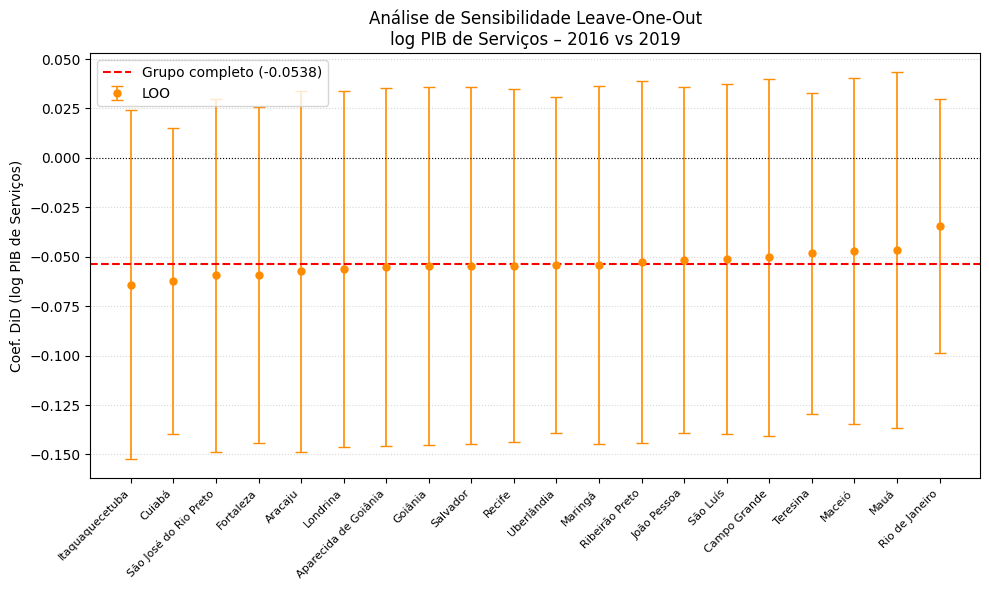

In [110]:
# ================================================================
# SEÇÃO 9: Leave-One-Out – log PIB de Serviços (2016 vs 2019)
# ================================================================

df_loo_serv = leave_one_out(
    df_matching,
    ids_controle_full,
    municipio_tratado,
    ano_pre_tratamento,
    ano_pos_serv,
    var_dep_serv,
    excluir_fixo_serv,
    mapa_id_nome,
)

linha_full_serv = pd.DataFrame([{
    "Município removido" : "— GRUPO COMPLETO —",
    "Coef. DiD"         : coef_serv,
    "Erro padrão"       : se_serv,
    "IC 2.5%"           : ci_low_serv,
    "IC 97.5%"          : ci_high_serv,
    "p-valor"           : p_serv,
    "N"                 : int(modelo_serv.nobs),
    "N covariáveis"     : len(covs_serv),
}])

df_loo_serv = (
    pd.concat([linha_full_serv, df_loo_serv], ignore_index=True)
    .sort_values("Coef. DiD")
    .reset_index(drop=True)
)

print(f"=== Leave-One-Out – log PIB de Serviços ({ano_pre_tratamento} vs 2019) ===")
print(df_loo_serv.to_string(index=False))

# ================================================================
# SEÇÃO 10: Gráfico Leave-One-Out – log PIB de Serviços (2016 vs 2019)
# ================================================================

df_loo_serv_plot = df_loo_serv[
    df_loo_serv["Município removido"] != "— GRUPO COMPLETO —"
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    range(len(df_loo_serv_plot)),
    df_loo_serv_plot["Coef. DiD"],
    yerr=[
        df_loo_serv_plot["Coef. DiD"] - df_loo_serv_plot["IC 2.5%"],
        df_loo_serv_plot["IC 97.5%"]  - df_loo_serv_plot["Coef. DiD"],
    ],
    fmt="o", color="darkorange", ecolor="darkorange",
    elinewidth=1.2, capsize=4, markersize=5, label="LOO",
)

ax.axhline(coef_serv, color="red", linestyle="--", linewidth=1.5,
           label=f"Grupo completo ({coef_serv:.4f})")
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")

ax.set_xticks(range(len(df_loo_serv_plot)))
ax.set_xticklabels(df_loo_serv_plot["Município removido"],
                   rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Coef. DiD (log PIB de Serviços)")
ax.set_title(f"Análise de Sensibilidade Leave-One-Out\nlog PIB de Serviços – {ano_pre_tratamento} vs 2019")
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()